In [1]:
# ============================================================
# SHARED SETUP — run this once before any algorithm section
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Consistent plot styling
plt.rcParams.update({
    'figure.dpi': 120,
    'figure.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11
})

# ─────────────────────────────────────────────
# Load the California Housing dataset
# ─────────────────────────────────────────────
# WHY THIS DATASET?
# • 20,640 samples — large enough for meaningful train/test splits
# • 8 features with real-world semantics (income, house age, etc.)
# • Continuous target (median house value in $100,000s)
# • No missing values, making it ideal for algorithmic comparisons
# • Publicly available and well-understood by the ML community

housing = fetch_california_housing(as_frame=True)
X, y = housing.data.copy(), housing.target.copy()

print("Dataset shape:", X.shape)
print("\nFeature descriptions:")
for name, desc in zip(housing.feature_names, housing.DESCR.split('\n')[13:21]):
    print(f"{name:12s}{desc.strip()}")
print(f"\nTarget:{housing.target_names[0]}")
print(f"  Range: [{y.min():.2f},{y.max():.2f}]")
print(f"  Mean:{y.mean():.2f} (i.e., ${y.mean()*100_000:,.0f})")

Dataset shape: (20640, 8)

Feature descriptions:
MedInc      - HouseAge      median house age in block group
HouseAge    - AveRooms      average number of rooms per household
AveRooms    - AveBedrms     average number of bedrooms per household
AveBedrms   - Population    block group population
Population  - AveOccup      average number of household members
AveOccup    - Latitude      block group latitude
Latitude    - Longitude     block group longitude
Longitude   

Target:MedHouseVal
  Range: [0.15,5.00]
  Mean:2.07 (i.e., $206,856)


In [2]:
# ─────────────────────────────────────────────
# Train-Test Split — the non-negotiable first step
# ─────────────────────────────────────────────

# WHY WE SPLIT:
# A model that memorizes training data will appear to perform perfectly
# in-sample but fail catastrophically on unseen data. The test set
# simulates "tomorrow's data" — it exists purely to estimate real-world
# generalization performance.
#
# KEY DECISIONS:
# • 80/20 split: Standard for datasets > 10K samples. With 20,640 rows,
#   our test set has 4,128 samples — more than enough for reliable estimates.
# • random_state=42: Reproducibility. Anyone running this code gets the
#   same split, making results comparable and debuggable.
# • Stratification: Not used here (continuous target), but for
#   classification, stratify=y ensures class balance in both splits.

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples:{len(X_train):,}")
print(f"Test samples:{len(X_test):,}")
print(f"\nTarget distribution check:")
print(f"  Train mean:{y_train.mean():.4f}  |  Test mean:{y_test.mean():.4f}")
print(f"  (Similar means confirm split didn't accidentally separate cheap/expensive houses)")

Training samples:16,512
Test samples:4,128

Target distribution check:
  Train mean:2.0719  |  Test mean:2.0550
  (Similar means confirm split didn't accidentally separate cheap/expensive houses)


In [3]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name="Model"):
    """
    Comprehensive model evaluation: metrics + interpretation.
    Returns a results dict for later comparison.
    """
    train_preds = model.predict(X_train)
    test_preds  = model.predict(X_test)

    results = {
        'name': model_name,
        'train_rmse': np.sqrt(mean_squared_error(y_train, train_preds)),
        'test_rmse':  np.sqrt(mean_squared_error(y_test,  test_preds)),
        'train_mae':  mean_absolute_error(y_train, train_preds),
        'test_mae':   mean_absolute_error(y_test,  test_preds),
        'train_r2':   r2_score(y_train, train_preds),
        'test_r2':    r2_score(y_test,  test_preds),
    }

    print(f"\n{'='*50}")
    print(f"{model_name} — Performance Summary")
    print(f"{'='*50}")
    print(f"{'Metric':<12}{'Train':>10}{'Test':>10}{'Overfit?':>10}")
    print(f"{'-'*46}")
    print(f"{'RMSE':<12}{results['train_rmse']:>10.4f}{results['test_rmse']:>10.4f}{'⚠️' if (results['train_rmse']/results['test_rmse']) < 0.85 else '✓':>10}")
    print(f"{'MAE':<12}{results['train_mae']:>10.4f}{results['test_mae']:>10.4f}")
    print(f"{'R²':<12}{results['train_r2']:>10.4f}{results['test_r2']:>10.4f}")
    print(f"\n  Interpretation:")
    print(f"  • RMSE of{results['test_rmse']:.3f} means average error of ~${results['test_rmse']*100_000:,.0f}")
    print(f"  • R² ={results['test_r2']:.3f} means the model explains{results['test_r2']*100:.1f}% of price variance")

    return results

all_results = {}  # We'll populate this throughout the guide

Model Coefficients (standardized features):
  Intercept:2.0719
   Feature  Coefficient  Abs_Magnitude
  Latitude    -0.896929       0.896929
 Longitude    -0.869842       0.869842
    MedInc     0.854383       0.854383
 AveBedrms     0.339259       0.339259
  AveRooms    -0.294410       0.294410
  HouseAge     0.122546       0.122546
  AveOccup    -0.040829       0.040829
Population    -0.002308       0.002308

Interpretation guide:
  With standardized features, coefficient magnitude = relative importance
  Sign indicates direction of effect on house price

Linear Regression — Performance Summary
Metric           Train      Test  Overfit?
----------------------------------------------
RMSE            0.7197    0.7456         ✓
MAE             0.5286    0.5332
R²              0.6126    0.5758

  Interpretation:
  • RMSE of0.746 means average error of ~$74,558
  • R² =0.576 means the model explains57.6% of price variance


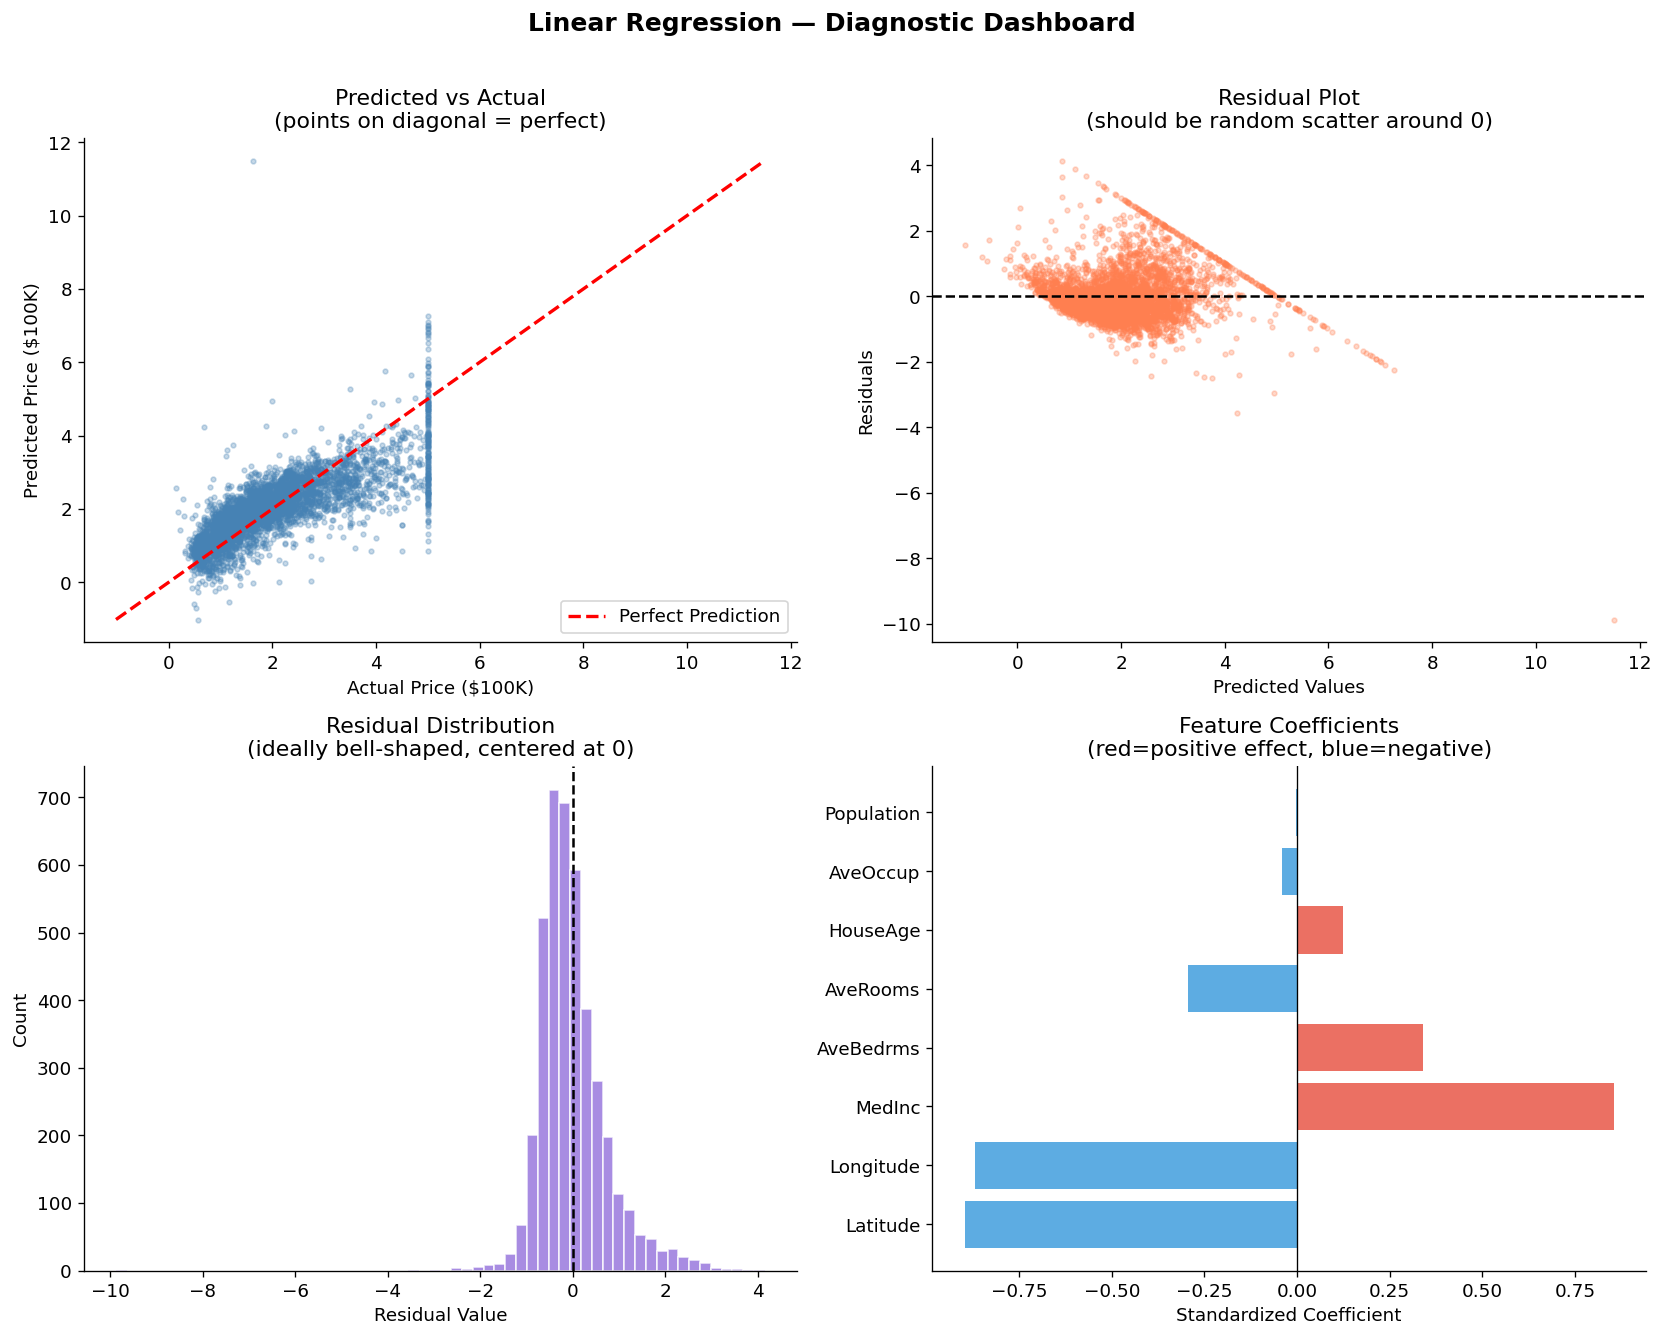

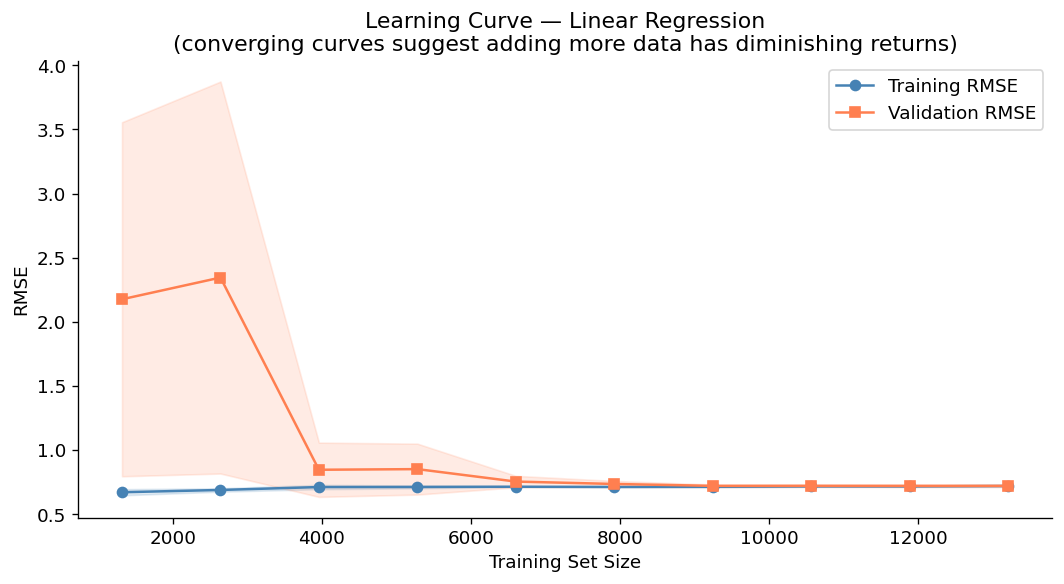


📈 How to improve Linear Regression:

1. POLYNOMIAL FEATURES: If residual plot shows curvature, add x² terms
   → from sklearn.preprocessing import PolynomialFeatures
   → poly = PolynomialFeatures(degree=2, include_bias=False)
   → X_poly = poly.fit_transform(X_train_scaled)

2. HANDLE OUTLIERS: High-leverage points can wildly distort coefficients
   → Use HuberRegressor for robustness to outliers
   → Or manually remove/cap extreme values

3. INTERACTION TERMS: "Rooms in a wealthy neighborhood" is worth more than
   rooms alone → add feature: MedInc × AveRooms

4. CROSS-VALIDATION: Get a reliable estimate of true performance
   → cv_scores = cross_val_score(lr_model, X_train_scaled, y_train,
                                  scoring='neg_root_mean_squared_error', cv=10)
   → print(f"CV RMSE: {-cv_scores.mean():.4f} ± {cv_scores.std():.4f}")



In [ ]:
# ============================================================
# LINEAR REGRESSION — Complete Implementation
# ============================================================

from sklearn.linear_model import LinearRegression

# ─── Step 1: Feature Scaling ───────────────────────────────
# WHY SCALE FOR LINEAR REGRESSION?
#
# Mathematically, OLS finds the same coefficients regardless of scale —
# so scaling is NOT strictly necessary for coefficient estimation.
#
# However, we scale here for two practical reasons:
# 1. Comparability: Scaled coefficients let us compare feature importance
#    (an unscaled β for "income" in units of $10K would dwarf β for "rooms")
# 2. Numerical stability: Large feature values can cause floating-point
#    precision issues in the normal equation
#
# CRITICAL RULE: Fit the scaler ONLY on training data, then transform both.
# If you fit on all data, you've leaked test set statistics into training —
# a subtle but real form of data leakage.

scaler_lr = StandardScaler()
X_train_scaled = scaler_lr.fit_transform(X_train)  # Fit AND transform train
X_test_scaled  = scaler_lr.transform(X_test)        # ONLY transform test

# ─── Step 2: Fit the Model ─────────────────────────────────
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# ─── Step 3: Inspect Coefficients ──────────────────────────
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_,
    'Abs_Magnitude': np.abs(lr_model.coef_)
}).sort_values('Abs_Magnitude', ascending=False)

print("Model Coefficients (standardized features):")
print(f"  Intercept:{lr_model.intercept_:.4f}")
print(coef_df.to_string(index=False))
print("\nInterpretation guide:")
print("  With standardized features, coefficient magnitude = relative importance")
print("  Sign indicates direction of effect on house price")

# ─── Step 4: Evaluate ──────────────────────────────────────
lr_results = evaluate_model(
    lr_model, X_train_scaled, X_test_scaled,
    y_train, y_test, "Linear Regression"
)
all_results['Linear Regression'] = lr_results

# ─── Step 5: Visualizations ────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle('Linear Regression — Diagnostic Dashboard', fontsize=15, fontweight='bold', y=1.01)

test_preds_lr = lr_model.predict(X_test_scaled)
residuals_lr  = y_test - test_preds_lr

# Plot 1: Predicted vs Actual
ax = axes[0, 0]
ax.scatter(y_test, test_preds_lr, alpha=0.3, s=8, color='steelblue')
lims = [min(y_test.min(), test_preds_lr.min()), max(y_test.max(), test_preds_lr.max())]
ax.plot(lims, lims, 'r--', lw=2, label='Perfect Prediction')
ax.set_xlabel('Actual Price ($100K)')
ax.set_ylabel('Predicted Price ($100K)')
ax.set_title('Predicted vs Actual\n(points on diagonal = perfect)')
ax.legend()
# The "ceiling" effect at y=5 is because California Housing caps prices at $500K

# Plot 2: Residual Plot
ax = axes[0, 1]
ax.scatter(test_preds_lr, residuals_lr, alpha=0.3, s=8, color='coral')
ax.axhline(0, color='black', linewidth=1.5, linestyle='--')
ax.set_xlabel('Predicted Values')
ax.set_ylabel('Residuals')
ax.set_title('Residual Plot\n(should be random scatter around 0)')
# If you see a funnel or curve shape here → heteroscedasticity or non-linearity

# Plot 3: Residual Distribution (test for normality assumption)
ax = axes[1, 0]
ax.hist(residuals_lr, bins=60, color='mediumpurple', edgecolor='white', alpha=0.8)
ax.axvline(0, color='black', linewidth=1.5, linestyle='--')
ax.set_xlabel('Residual Value')
ax.set_ylabel('Count')
ax.set_title('Residual Distribution\n(ideally bell-shaped, centered at 0)')

# Plot 4: Feature Coefficients (Importance)
ax = axes[1, 1]
colors = ['#e74c3c' if c > 0 else '#3498db' for c in coef_df['Coefficient']]
bars = ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, alpha=0.8)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Standardized Coefficient')
ax.set_title('Feature Coefficients\n(red=positive effect, blue=negative)')

plt.tight_layout()
plt.savefig('linear_regression_diagnostics.png', bbox_inches='tight')
plt.show()

# ─── Step 6: Learning Curve ────────────────────────────────
# A learning curve shows how model performance changes as training set
# size grows. Key insights:
# • High training error + high validation error → UNDERFITTING (high bias)
# • Low training error + high validation error → OVERFITTING (high variance)
# • Both errors converge → Adding more data won't help much

train_sizes, train_scores, val_scores = learning_curve(
    LinearRegression(), X_train_scaled, y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='neg_root_mean_squared_error',
    cv=5, n_jobs=-1
)

# Convert from negative RMSE back to positive
train_rmse = -  .mean(axis=1)
val_rmse   = -val_scores.mean(axis=1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(train_sizes, train_rmse, 'o-', label='Training RMSE', color='steelblue')
ax.plot(train_sizes, val_rmse,   's-', label='Validation RMSE', color='coral')
ax.fill_between(train_sizes,
    train_rmse - (-train_scores).std(axis=1),
    train_rmse + (-train_scores).std(axis=1),
    alpha=0.15, color='steelblue')
ax.fill_between(train_sizes,
    val_rmse   - (-val_scores).std(axis=1),
    val_rmse   + (-val_scores).std(axis=1),
    alpha=0.15, color='coral')
ax.set_xlabel('Training Set Size')
ax.set_ylabel('RMSE')
ax.set_title('Learning Curve — Linear Regression\n(converging curves suggest adding more data has diminishing returns)')
ax.legend()
plt.tight_layout()
plt.savefig('linear_regression_learning_curve.png', bbox_inches='tight')
plt.show()

# ─── Step 7: How to Improve This Model ──────────────────────
print("\n📈 How to improve Linear Regression:")
print("""
1. POLYNOMIAL FEATURES: If residual plot shows curvature, add x² terms
   → from sklearn.preprocessing import PolynomialFeatures
   → poly = PolynomialFeatures(degree=2, include_bias=False)
   → X_poly = poly.fit_transform(X_train_scaled)

2. HANDLE OUTLIERS: High-leverage points can wildly distort coefficients
   → Use HuberRegressor for robustness to outliers
   → Or manually remove/cap extreme values

3. INTERACTION TERMS: "Rooms in a wealthy neighborhood" is worth more than
   rooms alone → add feature: MedInc × AveRooms

4. CROSS-VALIDATION: Get a reliable estimate of true performance
   → cv_scores = cross_val_score(lr_model, X_train_scaled, y_train,
                                  scoring='neg_root_mean_squared_error', cv=10)
   → print(f"CV RMSE: {-cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
""")

Optimal alpha found by RidgeCV:1.2915
(Higher values = more regularization = more coefficient shrinkage)

Coefficient Shrinkage by Ridge:
   Feature  OLS Coefficient  Ridge Coefficient  Shrinkage %
    MedInc           0.8544             0.8543       0.0085
  HouseAge           0.1225             0.1226      -0.0819
  AveRooms          -0.2944            -0.2942       0.0876
 AveBedrms           0.3393             0.3389       0.0958
Population          -0.0023            -0.0023       1.4276
  AveOccup          -0.0408            -0.0408      -0.0124
  Latitude          -0.8969            -0.8959       0.1096
 Longitude          -0.8698            -0.8688       0.1145

Ridge Regression — Performance Summary
Metric           Train      Test  Overfit?
----------------------------------------------
RMSE            0.7197    0.7455         ✓
MAE             0.5286    0.5332
R²              0.6126    0.5758

  Interpretation:
  • RMSE of0.746 means average error of ~$74,555
  • R² =0.576 m

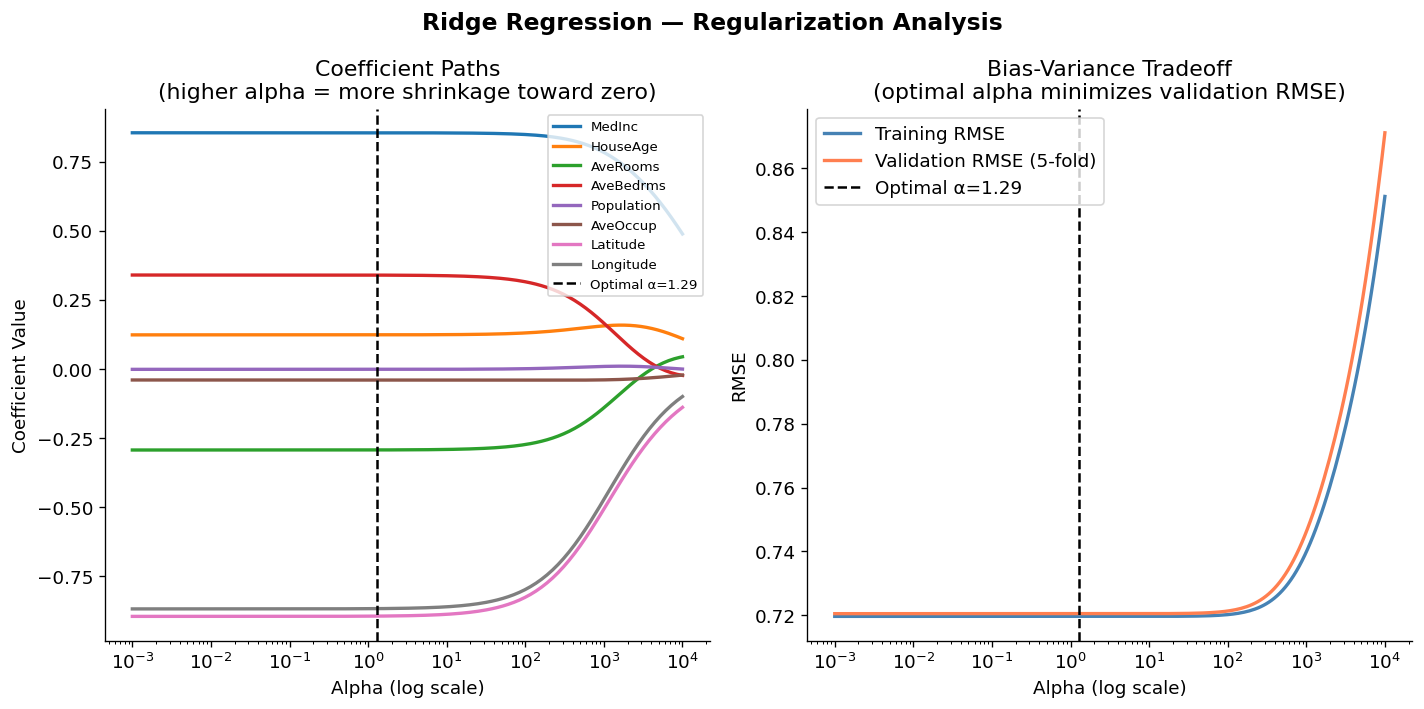

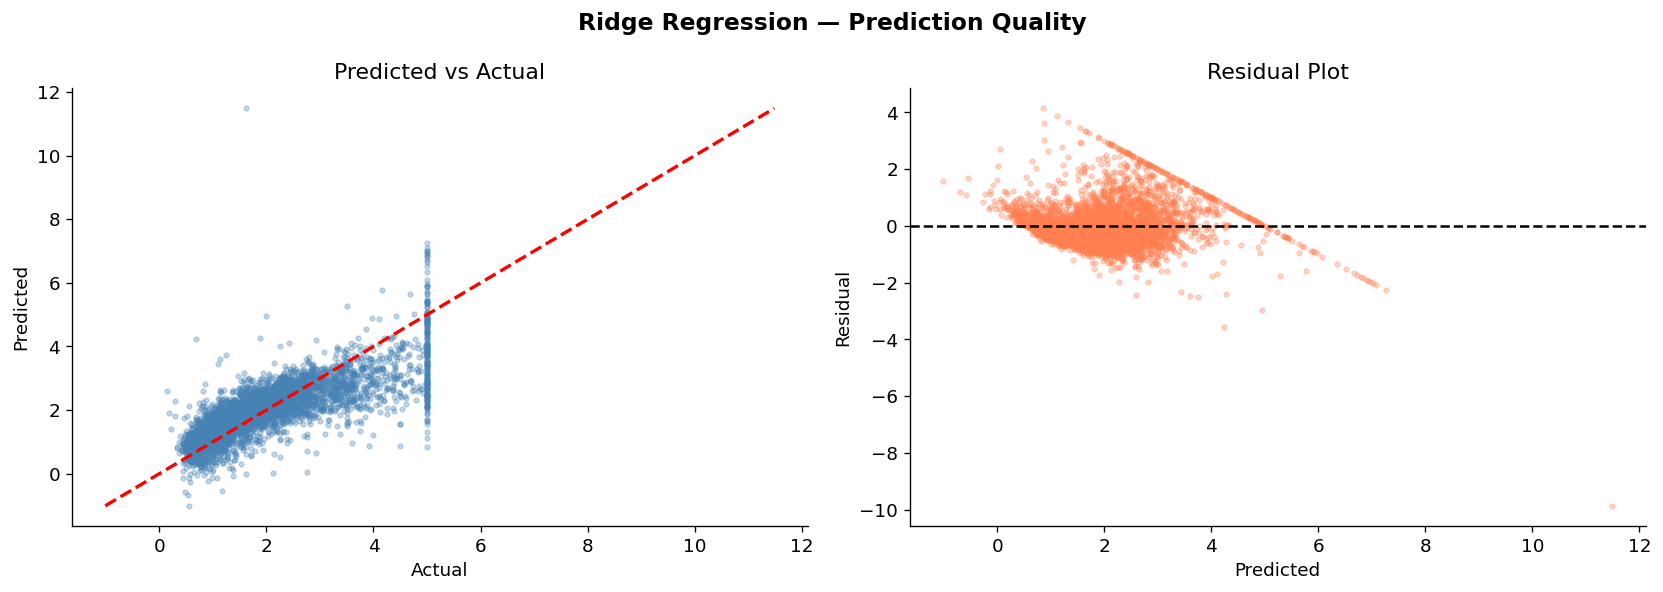


📈 When Ridge excels vs. Linear Regression:

• Correlated features (e.g., MedInc correlated with AveRooms): Ridge is more stable
• p > n situations: Ridge always has a unique solution; OLS does not
• When you want to KEEP all features but control their magnitudes
• Ridge almost always outperforms plain OLS in practice — regularization is cheap insurance



In [5]:
# ============================================================
# RIDGE REGRESSION — Complete Implementation
# ============================================================

from sklearn.linear_model import Ridge, RidgeCV

# Reuse scaled data from Linear Regression (same scaler)
# WHY SCALE FOR RIDGE?
# CRITICAL — unlike plain OLS, Ridge's penalty is SCALE-DEPENDENT.
# A feature measured in meters vs. kilometers would have coefficients
# that differ by 1000×, making the penalty treat them very differently.
# Standardizing ensures each feature is penalized fairly.
X_train_scaled_r = X_train_scaled  # Already scaled above
X_test_scaled_r  = X_test_scaled

# ─── Step 1: Find Optimal Alpha with RidgeCV ───────────────
# RidgeCV uses generalized cross-validation (GCV), which is an efficient
# approximation of leave-one-out CV. It tries all alphas in a single fit.
alphas = np.logspace(-3, 4, 100)  # 0.001 to 10,000 on log scale

ridge_cv = RidgeCV(alphas=alphas, cv=10, scoring='neg_root_mean_squared_error')
ridge_cv.fit(X_train_scaled_r, y_train)

print(f"Optimal alpha found by RidgeCV:{ridge_cv.alpha_:.4f}")
print(f"(Higher values = more regularization = more coefficient shrinkage)")

# ─── Step 2: Fit Final Model ───────────────────────────────
ridge_model = Ridge(alpha=ridge_cv.alpha_)
ridge_model.fit(X_train_scaled_r, y_train)

# ─── Step 3: Coefficient Comparison ────────────────────────
# The key diagnostic: how much did Ridge shrink the OLS coefficients?
lr_coefs    = lr_model.coef_
ridge_coefs = ridge_model.coef_

shrinkage_df = pd.DataFrame({
    'Feature': X.columns,
    'OLS Coefficient': lr_coefs,
    'Ridge Coefficient': ridge_coefs,
    'Shrinkage %': (1 - np.abs(ridge_coefs) / np.abs(lr_coefs)) * 100
}).round(4)

print("\nCoefficient Shrinkage by Ridge:")
print(shrinkage_df.to_string(index=False))

# ─── Step 4: Evaluate ──────────────────────────────────────
ridge_results = evaluate_model(
    ridge_model, X_train_scaled_r, X_test_scaled_r,
    y_train, y_test, "Ridge Regression"
)
all_results['Ridge Regression'] = ridge_results

# ─── Step 5: Alpha Sensitivity Analysis ────────────────────
# This is the most important diagnostic for Ridge — how do coefficients
# and performance change as we vary alpha?

alphas_plot = np.logspace(-3, 4, 200)
coef_paths = []
train_rmse_path, val_rmse_path = [], []

for a in alphas_plot:
    r = Ridge(alpha=a).fit(X_train_scaled_r, y_train)
    coef_paths.append(r.coef_)
    train_rmse_path.append(np.sqrt(mean_squared_error(y_train, r.predict(X_train_scaled_r))))
    val_scores = cross_val_score(Ridge(alpha=a), X_train_scaled_r, y_train,
                                  scoring='neg_root_mean_squared_error', cv=5)
    val_rmse_path.append(-val_scores.mean())

coef_paths = np.array(coef_paths)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
fig.suptitle('Ridge Regression — Regularization Analysis', fontsize=14, fontweight='bold')

# Coefficient paths — shows how each coefficient shrinks as alpha increases
ax = axes[0]
for i, name in enumerate(X.columns):
    ax.plot(alphas_plot, coef_paths[:, i], label=name, linewidth=2)
ax.axvline(ridge_cv.alpha_, color='black', linestyle='--', linewidth=1.5,
           label=f'Optimal α={ridge_cv.alpha_:.2f}')
ax.set_xscale('log')
ax.set_xlabel('Alpha (log scale)')
ax.set_ylabel('Coefficient Value')
ax.set_title('Coefficient Paths\n(higher alpha = more shrinkage toward zero)')
ax.legend(fontsize=8, loc='upper right')

# Train vs. Validation RMSE across alpha values
ax = axes[1]
ax.plot(alphas_plot, train_rmse_path, label='Training RMSE', color='steelblue', linewidth=2)
ax.plot(alphas_plot, val_rmse_path,   label='Validation RMSE (5-fold)', color='coral', linewidth=2)
ax.axvline(ridge_cv.alpha_, color='black', linestyle='--', linewidth=1.5,
           label=f'Optimal α={ridge_cv.alpha_:.2f}')
ax.set_xscale('log')
ax.set_xlabel('Alpha (log scale)')
ax.set_ylabel('RMSE')
ax.set_title('Bias-Variance Tradeoff\n(optimal alpha minimizes validation RMSE)')
ax.legend()

plt.tight_layout()
plt.savefig('ridge_regularization_analysis.png', bbox_inches='tight')
plt.show()

# ─── Step 6: Predicted vs Actual ───────────────────────────
test_preds_ridge = ridge_model.predict(X_test_scaled_r)
residuals_ridge  = y_test - test_preds_ridge

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Ridge Regression — Prediction Quality', fontsize=14, fontweight='bold')

ax = axes[0]
ax.scatter(y_test, test_preds_ridge, alpha=0.3, s=8, color='steelblue')
lims = [min(y_test.min(), test_preds_ridge.min()), max(y_test.max(), test_preds_ridge.max())]
ax.plot(lims, lims, 'r--', lw=2)
ax.set_xlabel('Actual'); ax.set_ylabel('Predicted')
ax.set_title('Predicted vs Actual')

ax = axes[1]
ax.scatter(test_preds_ridge, residuals_ridge, alpha=0.3, s=8, color='coral')
ax.axhline(0, color='black', linewidth=1.5, linestyle='--')
ax.set_xlabel('Predicted'); ax.set_ylabel('Residual')
ax.set_title('Residual Plot')

plt.tight_layout()
plt.savefig('ridge_predictions.png', bbox_inches='tight')
plt.show()

print("\n📈 When Ridge excels vs. Linear Regression:")
print("""
• Correlated features (e.g., MedInc correlated with AveRooms): Ridge is more stable
• p > n situations: Ridge always has a unique solution; OLS does not
• When you want to KEEP all features but control their magnitudes
• Ridge almost always outperforms plain OLS in practice — regularization is cheap insurance
""")

Optimal alpha:0.000811

Coefficients set to exactly zero: 0 /8
Active features:8 /8

Non-zero coefficients (selected features):
MedInc         :+0.8501
HouseAge       :+0.1232
AveRooms       :-0.2838
AveBedrms      :+0.3286
Population     :-0.0013
AveOccup       :-0.0401
Latitude       :-0.8879
Longitude      :-0.8603

Lasso Regression — Performance Summary
Metric           Train      Test  Overfit?
----------------------------------------------
RMSE            0.7197    0.7448         ✓
MAE             0.5287    0.5332
R²              0.6125    0.5767

  Interpretation:
  • RMSE of0.745 means average error of ~$74,481
  • R² =0.577 means the model explains57.7% of price variance


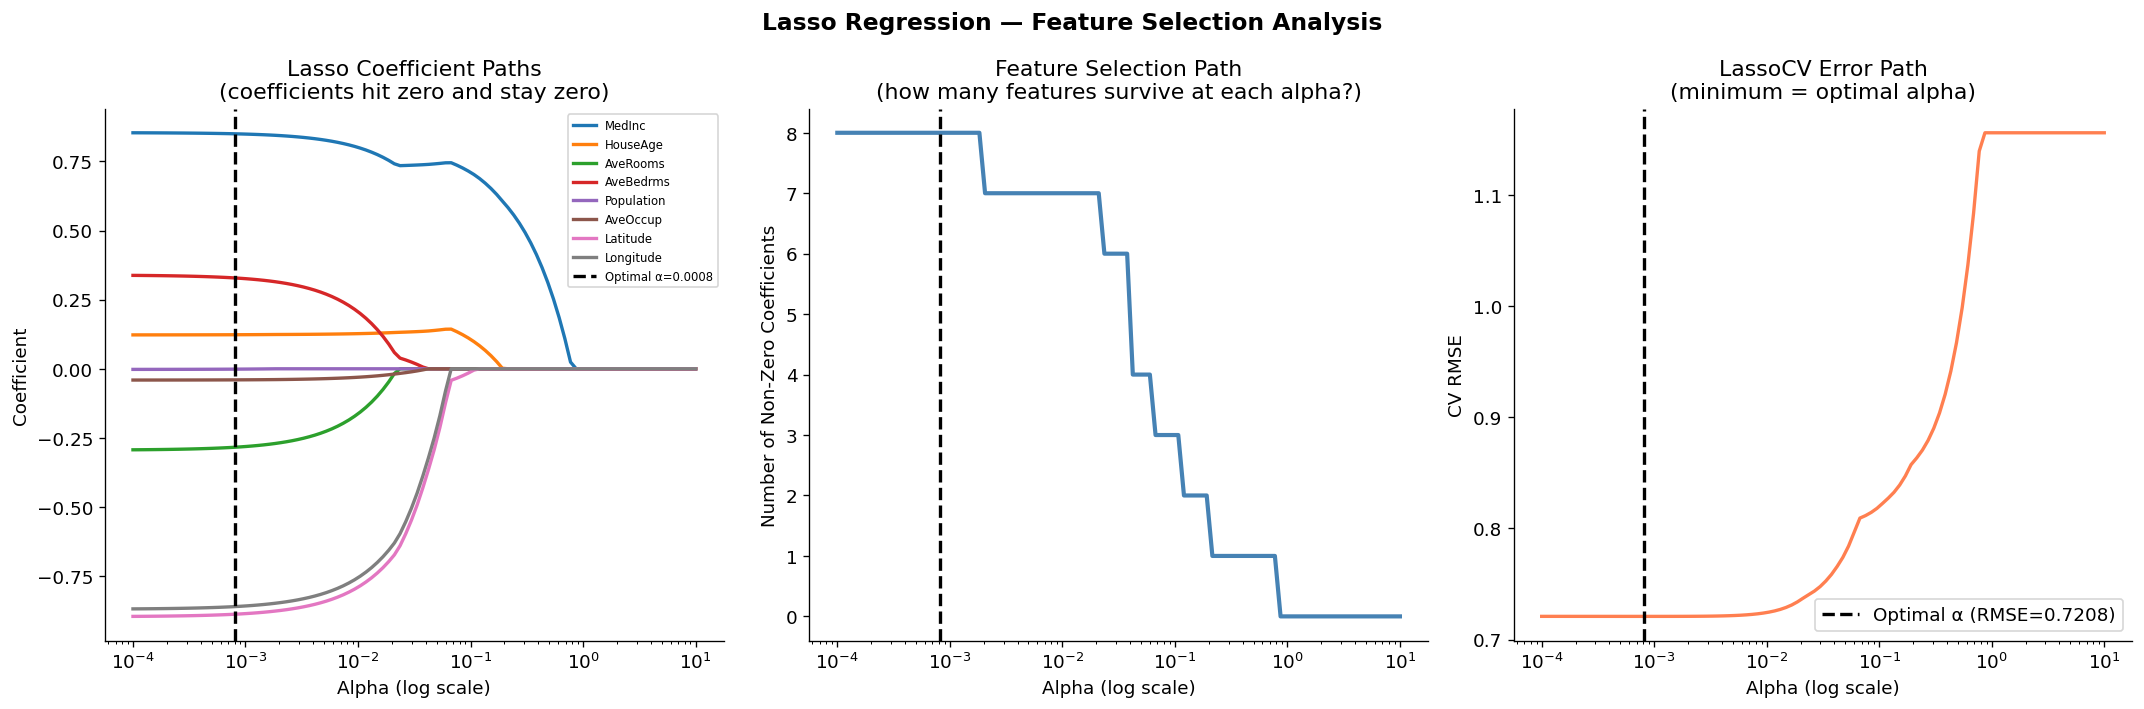


Feature Selection Comparison Across Methods:
   Feature     OLS   Ridge   Lasso  Lasso_Selected
    MedInc  0.8544  0.8543  0.8501            True
  HouseAge  0.1225  0.1226  0.1232            True
  AveRooms -0.2944 -0.2942 -0.2838            True
 AveBedrms  0.3393  0.3389  0.3286            True
Population -0.0023 -0.0023 -0.0013            True
  AveOccup -0.0408 -0.0408 -0.0401            True
  Latitude -0.8969 -0.8959 -0.8879            True
 Longitude -0.8698 -0.8688 -0.8603            True

📈 When Lasso excels vs. Ridge:

• True sparsity: When you believe most features are irrelevant (genomics, NLP)
• Automatic feature selection: Lasso tells you which features matter
• High-dimensional data: More features than samples — Lasso can handle p >> n
• Interpretability requirement: Sparse models with 3-5 features are easier to explain

are nearly identical, Lasso may arbitrarily zero one out. For correlated features,
Ridge or Elastic Net is more stable.



In [6]:
# ============================================================
# LASSO REGRESSION — Complete Implementation
# ============================================================

from sklearn.linear_model import Lasso, LassoCV
from sklearn.linear_model import lars_path  # For regularization path

# WHY SCALE FOR LASSO?
# More critical than for Ridge! Lasso penalizes |β| — if a feature has
# coefficient 1000 (due to small scale), it gets penalized 1000× more
# than a feature with coefficient 1. Standardizing ensures the L1
# penalty is applied equally across all features.

# ─── Step 1: Find Optimal Alpha ────────────────────────────
# LassoCV efficiently computes solutions for many alphas using
# warm starts — each solution initializes from the previous one

lasso_cv = LassoCV(
    alphas=np.logspace(-4, 1, 100),
    cv=10,
    max_iter=10000,    # Must increase — Lasso's coordinate descent needs many iterations
    n_jobs=-1
)
lasso_cv.fit(X_train_scaled, y_train)

print(f"Optimal alpha:{lasso_cv.alpha_:.6f}")
print(f"\nCoefficients set to exactly zero: "
      f"{np.sum(lasso_cv.coef_ == 0)} /{len(lasso_cv.coef_)}")
print(f"Active features:{np.sum(lasso_cv.coef_ != 0)} /{len(lasso_cv.coef_)}")
print("\nNon-zero coefficients (selected features):")
for name, coef in zip(X.columns, lasso_cv.coef_):
    status = f"{name:15s}:{coef:+.4f}"
    if coef == 0:
        status += "  ← ELIMINATED"
    print(status)

# ─── Step 2: Fit Final Model ───────────────────────────────
lasso_model = Lasso(alpha=lasso_cv.alpha_, max_iter=10000)
lasso_model.fit(X_train_scaled, y_train)

# ─── Step 3: Evaluate ──────────────────────────────────────
lasso_results = evaluate_model(
    lasso_model, X_train_scaled, X_test_scaled,
    y_train, y_test, "Lasso Regression"
)
all_results['Lasso Regression'] = lasso_results

# ─── Step 4: LassoCV Path — The Key Visualization ──────────
# This shows how many features are "active" at each alpha value,
# and what the cross-validation RMSE is along the path.

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Lasso Regression — Feature Selection Analysis', fontsize=14, fontweight='bold')

# Plot 1: Coefficient paths vs. alpha
alphas_path = lasso_cv.alphas_
coef_path   = []
for a in alphas_path:
    m = Lasso(alpha=a, max_iter=10000).fit(X_train_scaled, y_train)
    coef_path.append(m.coef_)
coef_path = np.array(coef_path)

ax = axes[0]
for i, name in enumerate(X.columns):
    ax.plot(alphas_path, coef_path[:, i], label=name, linewidth=2)
ax.axvline(lasso_cv.alpha_, color='black', linestyle='--', linewidth=2,
           label=f'Optimal α={lasso_cv.alpha_:.4f}')
ax.set_xscale('log')
ax.set_xlabel('Alpha (log scale)')
ax.set_ylabel('Coefficient')
ax.set_title('Lasso Coefficient Paths\n(coefficients hit zero and stay zero)')
ax.legend(fontsize=7)

# Plot 2: Number of active features vs. alpha
n_active = (coef_path != 0).sum(axis=1)
ax = axes[1]
ax.plot(alphas_path, n_active, color='steelblue', linewidth=2.5)
ax.axvline(lasso_cv.alpha_, color='black', linestyle='--', linewidth=2)
ax.set_xscale('log')
ax.set_xlabel('Alpha (log scale)')
ax.set_ylabel('Number of Non-Zero Coefficients')
ax.set_title('Feature Selection Path\n(how many features survive at each alpha?)')
ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))

# Plot 3: Cross-validation error path
mse_path = lasso_cv.mse_path_.mean(axis=-1)  # Average MSE across CV folds
rmse_path = np.sqrt(mse_path)

ax = axes[2]
ax.plot(lasso_cv.alphas_, rmse_path, color='coral', linewidth=2)
ax.axvline(lasso_cv.alpha_, color='black', linestyle='--', linewidth=2,
           label=f'Optimal α (RMSE={np.sqrt(lasso_cv.mse_path_[np.argmin(mse_path)].mean()):.4f})')
ax.set_xscale('log')
ax.set_xlabel('Alpha (log scale)')
ax.set_ylabel('CV RMSE')
ax.set_title('LassoCV Error Path\n(minimum = optimal alpha)')
ax.legend()

plt.tight_layout()
plt.savefig('lasso_analysis.png', bbox_inches='tight')
plt.show()

# ─── Step 5: Feature Selection Summary ─────────────────────
lasso_feature_df = pd.DataFrame({
    'Feature': X.columns,
    'OLS': lr_model.coef_,
    'Ridge': ridge_model.coef_,
    'Lasso': lasso_model.coef_,
}).round(4)
lasso_feature_df['Lasso_Selected'] = lasso_feature_df['Lasso'] != 0

print("\nFeature Selection Comparison Across Methods:")
print(lasso_feature_df.to_string(index=False))

print("\n📈 When Lasso excels vs. Ridge:")
print("""
• True sparsity: When you believe most features are irrelevant (genomics, NLP)
• Automatic feature selection: Lasso tells you which features matter
• High-dimensional data: More features than samples — Lasso can handle p >> n
• Interpretability requirement: Sparse models with 3-5 features are easier to explain

WARNING: Lasso is unstable when features are highly correlated. If two features
are nearly identical, Lasso may arbitrarily zero one out. For correlated features,
Ridge or Elastic Net is more stable.
""")

Optimal alpha:0.000829
Optimal l1_ratio:0.99
  → l1_ratio=0.99 means99% L1,1% L2

Features selected:8 /8

Elastic Net — Performance Summary
Metric           Train      Test  Overfit?
----------------------------------------------
RMSE            0.7197    0.7448         ✓
MAE             0.5287    0.5332
R²              0.6125    0.5767

  Interpretation:
  • RMSE of0.745 means average error of ~$74,480
  • R² =0.577 means the model explains57.7% of price variance

Coefficient Comparison: Ridge vs. Lasso vs. Elastic Net
   Feature   Ridge   Lasso  Elastic Net
    MedInc  0.8543  0.8501       0.8501
  HouseAge  0.1226  0.1232       0.1232
  AveRooms -0.2942 -0.2838      -0.2836
 AveBedrms  0.3389  0.3286       0.3284
Population -0.0023 -0.0013      -0.0013
  AveOccup -0.0408 -0.0401      -0.0401
  Latitude -0.8959 -0.8879      -0.8877
 Longitude -0.8688 -0.8603      -0.8601


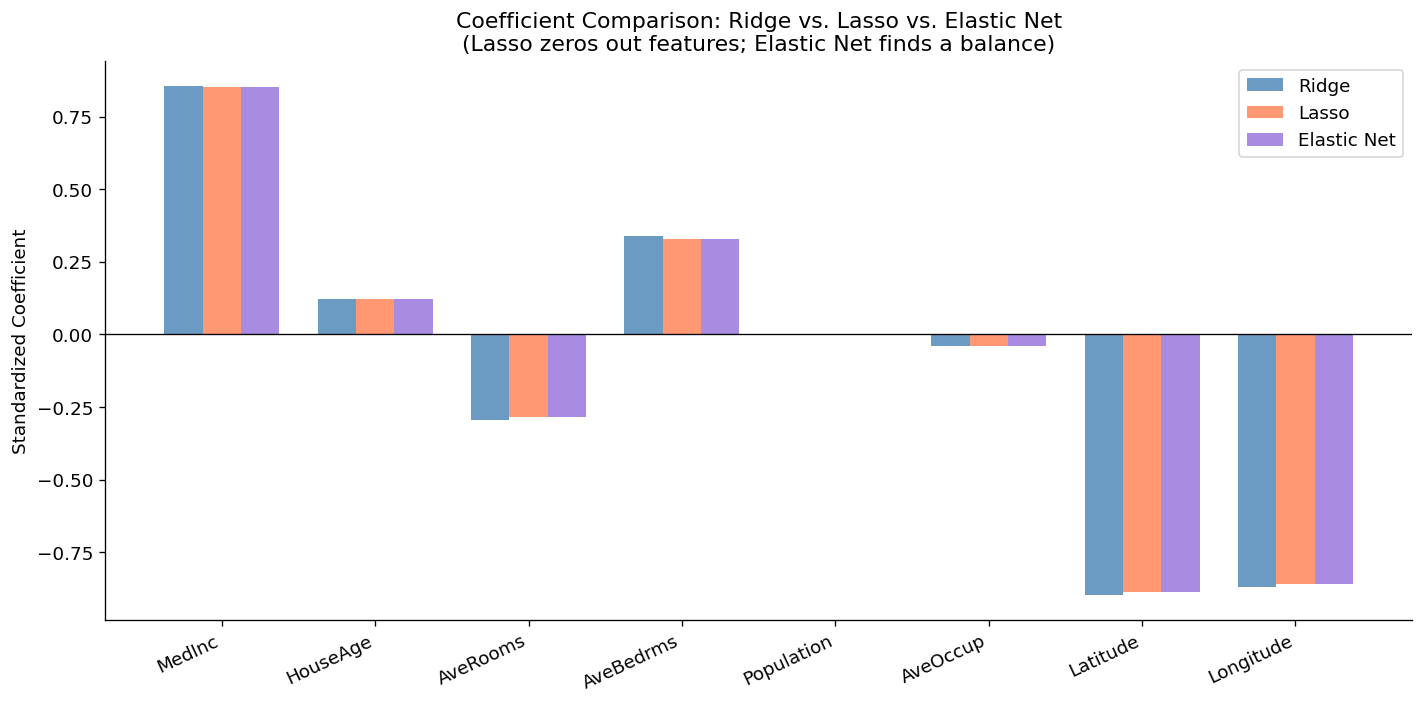

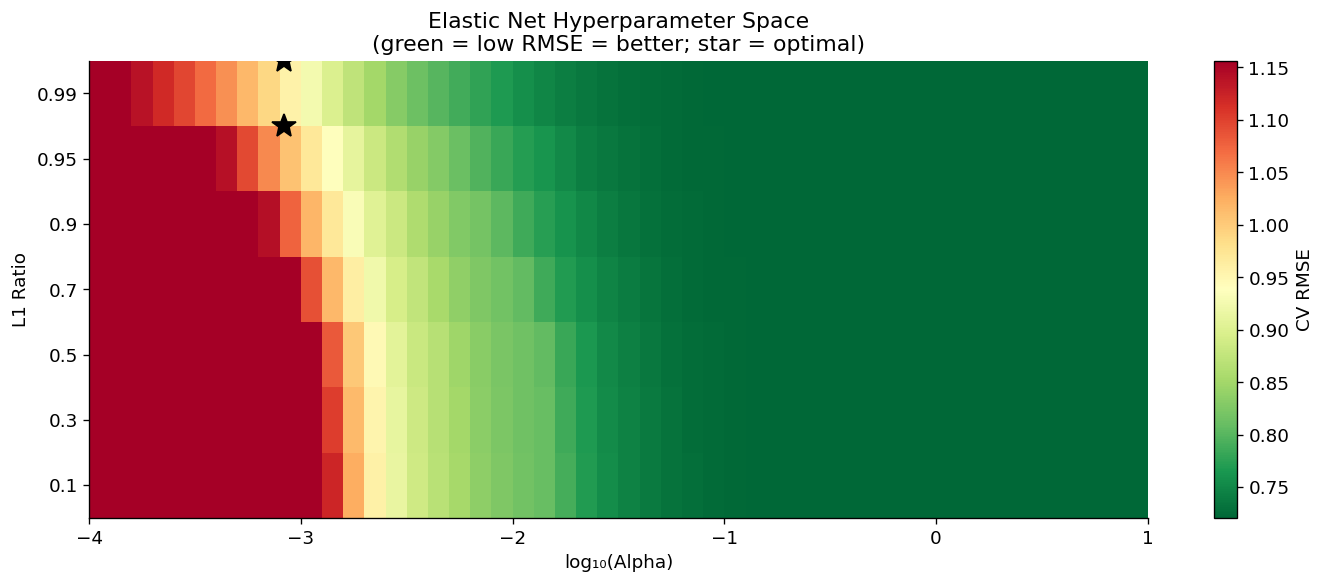


📈 When to use Elastic Net over Lasso or Ridge:

• Correlated features + sparsity desired: Elastic Net groups correlated features
  and applies coordinated shrinkage, unlike Lasso which picks one arbitrarily
• p >> n with groups of related features: Elastic Net handles this better than Lasso
• Gene expression, text data: Many features that come in correlated groups
• When LassoCV and RidgeCV give similar performance: Try Elastic Net as a compromise
• The "default regularized linear model" when you're uncertain — it generalizes both



In [ ]:
# ============================================================
# ELASTIC NET — Complete Implementation
# ============================================================

from sklearn.linear_model import ElasticNet, ElasticNetCV

# ─── Step 1: Two-Dimensional Cross-Validation ───────────────
# ElasticNetCV optimizes both alpha and l1_ratio simultaneously.
# This is the most expensive search among the linear models —
# we're exploring a 2D hyperparameter space.

l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99]

en_cv = ElasticNetCV(
    l1_ratio=l1_ratios,         # Try these L1/L2 mixes
    alphas=np.logspace(-4, 1, 50),
    cv=10,
    max_iter=10000,
    n_jobs=-1
)
en_cv.fit(X_train_scaled, y_train)

print(f"Optimal alpha:{en_cv.alpha_:.6f}")
print(f"Optimal l1_ratio:{en_cv.l1_ratio_:.2f}")
print(f"  → l1_ratio={en_cv.l1_ratio_:.2f} means{en_cv.l1_ratio_*100:.0f}% L1,{(1-en_cv.l1_ratio_)*100:.0f}% L2")
print(f"\nFeatures selected:{np.sum(en_cv.coef_ != 0)} /{len(en_cv.coef_)}")

# ─── Step 2: Fit Final Model ───────────────────────────────
en_model = ElasticNet(alpha=en_cv.alpha_, l1_ratio=en_cv.l1_ratio_,)
en_model.fit(X_train_scaled, y_train)

# ─── Step 3: Evaluate ──────────────────────────────────────
en_results = evaluate_model(
    en_model, X_train_scaled, X_test_scaled,
    y_train, y_test, "Elastic Net"
)
all_results['Elastic Net'] = en_results

# ─── Step 4: Side-by-Side Coefficient Comparison ───────────
# The key question: how do Lasso and Elastic Net differ in coefficient allocation?
compare_df = pd.DataFrame({
    'Feature':     X.columns,
    'Ridge':       ridge_model.coef_,
    'Lasso':       lasso_model.coef_,
    'Elastic Net': en_model.coef_,
}).round(4)

print("\nCoefficient Comparison: Ridge vs. Lasso vs. Elastic Net")
print(compare_df.to_string(index=False))

# ─── Step 5: Visualize Coefficient Comparison ──────────────
fig, ax = plt.subplots(figsize=(12, 6))

x_pos = np.arange(len(X.columns))
width = 0.25

bars1 = ax.bar(x_pos - width, ridge_model.coef_, width, label='Ridge', color='steelblue', alpha=0.8)
bars2 = ax.bar(x_pos,         lasso_model.coef_, width, label='Lasso', color='coral', alpha=0.8)
bars3 = ax.bar(x_pos + width, en_model.coef_,    width, label='Elastic Net', color='mediumpurple', alpha=0.8)

ax.set_xticks(x_pos)
ax.set_xticklabels(X.columns, rotation=25, ha='right')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Standardized Coefficient')
ax.set_title('Coefficient Comparison: Ridge vs. Lasso vs. Elastic Net\n(Lasso zeros out features; Elastic Net finds a balance)')
ax.legend()
plt.tight_layout()
plt.savefig('elastic_net_comparison.png', bbox_inches='tight')
plt.show()

# ─── Step 6: Heatmap of CV RMSE over alpha × l1_ratio ──────
# This is the 2D optimization landscape ElasticNetCV navigates
mse_paths = en_cv.mse_path_  # shape: (n_l1_ratios, n_alphas, n_folds)

fig, ax = plt.subplots(figsize=(12, 5))
rmse_heatmap = np.sqrt(mse_paths.mean(axis=-1))  # Average over folds

im = ax.imshow(rmse_heatmap, aspect='auto', cmap='RdYlGn_r',
               extent=[np.log10(en_cv.alphas_.min()), np.log10(en_cv.alphas_.max()),
                       0, len(l1_ratios)])
plt.colorbar(im, ax=ax, label='CV RMSE')
ax.set_yticks(np.arange(len(l1_ratios)) + 0.5)
ax.set_yticklabels([str(r) for r in l1_ratios])
ax.set_xlabel('log₁₀(Alpha)')
ax.set_ylabel('L1 Ratio')
ax.set_title('Elastic Net Hyperparameter Space\n(green = low RMSE = better; star = optimal)')

# Mark optimal
best_l1_idx = l1_ratios.index(en_cv.l1_ratio_)
best_a_pos = (np.log10(en_cv.alpha_) - np.log10(en_cv.alphas_.min())) / \
             (np.log10(en_cv.alphas_.max()) - np.log10(en_cv.alphas_.min())) * \
             (np.log10(en_cv.alphas_.max()) - np.log10(en_cv.alphas_.min()))
ax.plot([np.log10(en_cv.alpha_)]*2,
        [best_l1_idx, best_l1_idx + 1],
        'k*', markersize=15, label='Optimal')

plt.tight_layout()
plt.savefig('elastic_net_heatmap.png', bbox_inches='tight')
plt.show()

print("\n📈 When to use Elastic Net over Lasso or Ridge:")
print("""
• Correlated features + sparsity desired: Elastic Net groups correlated features
  and applies coordinated shrinkage, unlike Lasso which picks one arbitrarily
• p >> n with groups of related features: Elastic Net handles this better than Lasso
• Gene expression, text data: Many features that come in correlated groups
• When LassoCV and RidgeCV give similar performance: Try Elastic Net as a compromise
• The "default regularized linear model" when you're uncertain — it generalizes both
""")

OVERFIT TREE (no depth limit):
  Tree depth:34
  Leaf nodes:15,854
  Training R²:1.0000
  Test R²:0.6221
  → Gap shows extreme overfitting — the tree memorized training data

Optimal max_depth:9
Best params:{'max_depth': 10, 'min_samples_leaf': 20, 'min_samples_split': 2}

Decision Tree — Performance Summary
Metric           Train      Test  Overfit?
----------------------------------------------
RMSE            0.5345    0.6126         ✓
MAE             0.3656    0.4177
R²              0.7863    0.7137

  Interpretation:
  • RMSE of0.613 means average error of ~$61,256
  • R² =0.714 means the model explains71.4% of price variance


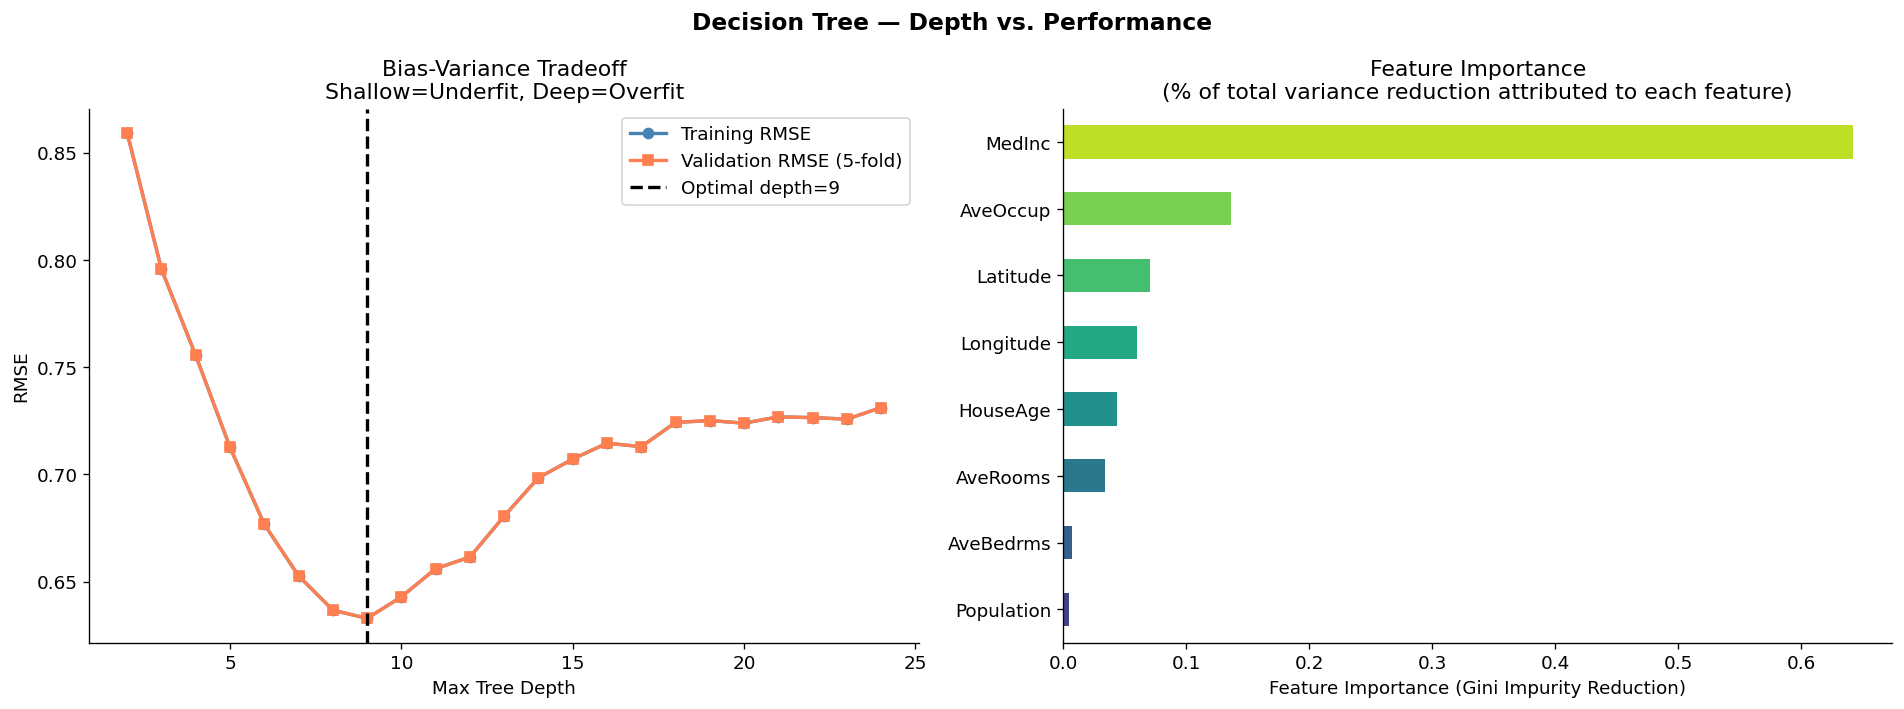

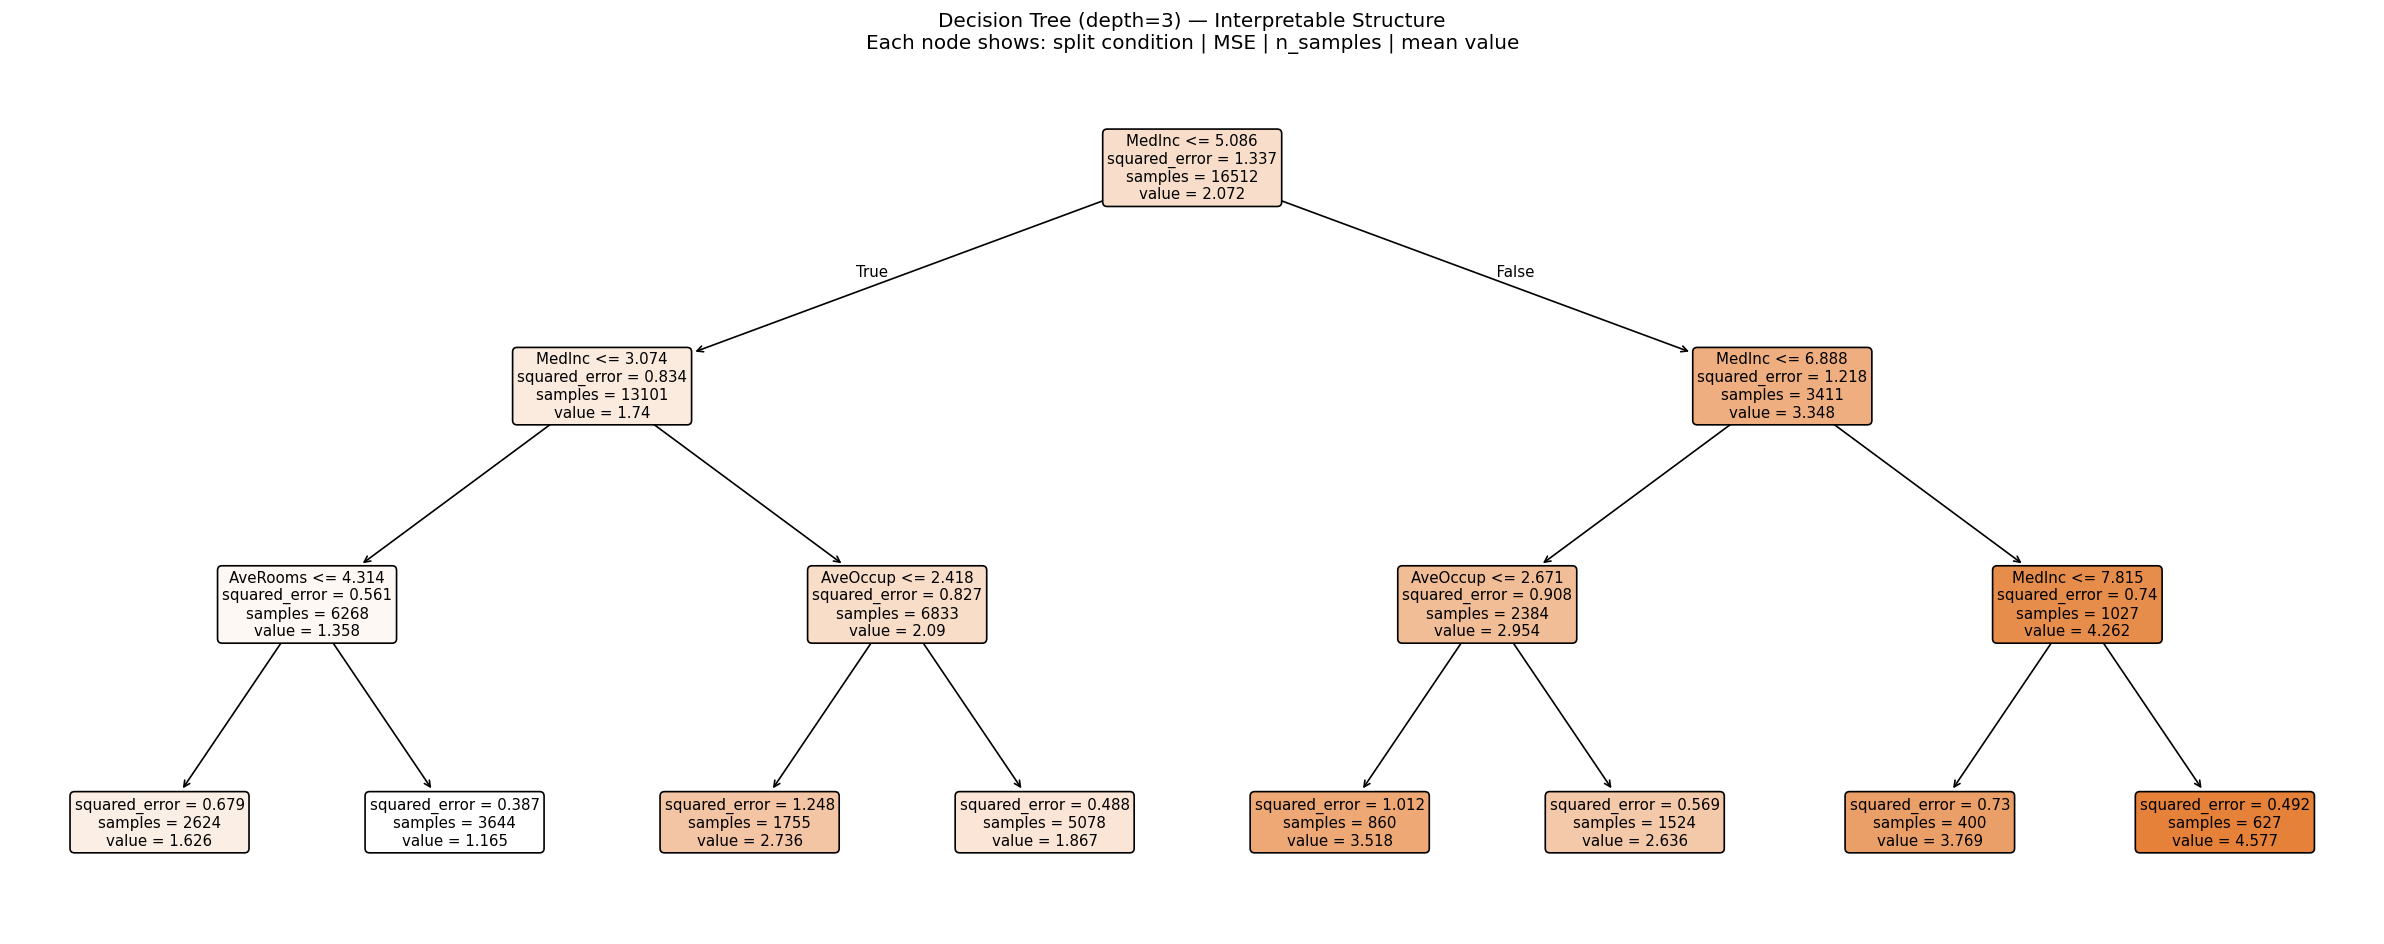


Post-pruning with Cost-Complexity Pruning (CCP):
Generated68 pruned trees. Use CV to pick best ccp_alpha.

📈 Key Decision Tree Insights:

• Always start by checking the depth — unlimited trees will memorize training data
• Feature importance from trees is reliable only for uncorrelated features
  (correlated features split importance between each other arbitrarily)
• Decision Trees excel at discovering non-linear thresholds automatically
• Single trees are almost always outperformed by ensembles (Random Forest, GBM)
  but are valuable for interpretability and as a diagnostic baseline



In [8]:
# ============================================================
# DECISION TREE REGRESSION — Complete Implementation
# ============================================================

from sklearn.tree import DecisionTreeRegressor, export_text, plot_tree
from sklearn.model_selection import GridSearchCV

# ─── WHY NO SCALING FOR DECISION TREES? ────────────────────
# Decision Trees split based on "is feature X < threshold?"
# The ORDER of values matters, not their magnitude. Whether income
# is measured in $1K units or $100K units, the same splits emerge.
# This is a huge practical advantage over linear models.

# ─── Step 1: Demonstrate Overfitting with Unlimited Tree ───
tree_overfit = DecisionTreeRegressor(random_state=42)  # No depth limit
tree_overfit.fit(X_train, y_train)

print("OVERFIT TREE (no depth limit):")
print(f"  Tree depth:{tree_overfit.get_depth()}")
print(f"  Leaf nodes:{tree_overfit.get_n_leaves():,}")
print(f"  Training R²:{r2_score(y_train, tree_overfit.predict(X_train)):.4f}")
print(f"  Test R²:{r2_score(y_test,  tree_overfit.predict(X_test)):.4f}")
print(f"  → Gap shows extreme overfitting — the tree memorized training data")

# ─── Step 2: Find Optimal Depth via Cross-Validation ───────
depths = range(2, 25)
cv_train_scores, cv_val_scores = [], []

for d in depths:
    dt = DecisionTreeRegressor(max_depth=d, random_state=42)
    train_score = cross_val_score(dt, X_train, y_train,
                                   scoring='neg_root_mean_squared_error', cv=5)
    cv_train_scores.append(-train_score.mean())

    val_score = cross_val_score(dt, X_train, y_train,
                                 scoring='neg_root_mean_squared_error', cv=5)
    cv_val_scores.append(-val_score.mean())

optimal_depth = depths[np.argmin(cv_val_scores)]
print(f"\nOptimal max_depth:{optimal_depth}")

# ─── Step 3: Refined Hyperparameter Search ─────────────────
param_grid = {
    'max_depth':         [optimal_depth - 1, optimal_depth, optimal_depth + 1],
    'min_samples_leaf':  [1, 5, 10, 20],
    'min_samples_split': [2, 10, 20]
}

grid_search_dt = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid,
    cv=10,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)
grid_search_dt.fit(X_train, y_train)
print(f"Best params:{grid_search_dt.best_params_}")

# ─── Step 4: Fit Final Model ───────────────────────────────
dt_model = DecisionTreeRegressor(**grid_search_dt.best_params_, random_state=42)
dt_model.fit(X_train, y_train)

# ─── Step 5: Evaluate ──────────────────────────────────────
dt_results = evaluate_model(
    dt_model, X_train, X_test, y_train, y_test, "Decision Tree"
)
all_results['Decision Tree'] = dt_results

# ─── Step 6: Visualize the Bias-Variance Tradeoff ──────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Decision Tree — Depth vs. Performance', fontsize=14, fontweight='bold')

# Train vs. Validation RMSE by depth
ax = axes[0]
ax.plot(depths, cv_train_scores, 'o-', label='Training RMSE', color='steelblue', linewidth=2)
ax.plot(depths, cv_val_scores,   's-', label='Validation RMSE (5-fold)', color='coral', linewidth=2)
ax.axvline(optimal_depth, color='black', linestyle='--', linewidth=2,
           label=f'Optimal depth={optimal_depth}')
ax.set_xlabel('Max Tree Depth')
ax.set_ylabel('RMSE')
ax.set_title('Bias-Variance Tradeoff\nShallow=Underfit, Deep=Overfit')
ax.legend()

# Feature Importance
ax = axes[1]
feature_importance = pd.Series(dt_model.feature_importances_, index=X.columns).sort_values()
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(X.columns)))
feature_importance.plot(kind='barh', ax=ax, color=colors)
ax.set_xlabel('Feature Importance (Gini Impurity Reduction)')
ax.set_title('Feature Importance\n(% of total variance reduction attributed to each feature)')

plt.tight_layout()
plt.savefig('decision_tree_analysis.png', bbox_inches='tight')
plt.show()

# ─── Step 7: Visualize the Tree (pruned to depth 3 for readability)
fig, ax = plt.subplots(figsize=(20, 8))
small_tree = DecisionTreeRegressor(max_depth=3, min_samples_leaf=100, random_state=42)
small_tree.fit(X_train, y_train)

plot_tree(
    small_tree,
    feature_names=list(X.columns),
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax
)
ax.set_title('Decision Tree (depth=3) — Interpretable Structure\n'
             'Each node shows: split condition | MSE | n_samples | mean value',
             fontsize=12)
plt.tight_layout()
plt.savefig('decision_tree_visualization.png', bbox_inches='tight')
plt.show()

# ─── Step 8: CCP Alpha Pruning ─────────────────────────────
# Post-pruning alternative: grow a full tree, then prune subtrees
# whose complexity cost exceeds ccp_alpha
print("\nPost-pruning with Cost-Complexity Pruning (CCP):")
path = dt_model.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

clfs = []
for ccp_alpha in ccp_alphas[::5]:  # Sample every 5th to save time
    clf = DecisionTreeRegressor(random_state=42, ccp_alpha=ccp_alpha)
    clf.fit(X_train, y_train)
    clfs.append(clf)

print(f"Generated{len(clfs)} pruned trees. Use CV to pick best ccp_alpha.")

print("\n📈 Key Decision Tree Insights:")
print("""
• Always start by checking the depth — unlimited trees will memorize training data
• Feature importance from trees is reliable only for uncorrelated features
  (correlated features split importance between each other arbitrarily)
• Decision Trees excel at discovering non-linear thresholds automatically
• Single trees are almost always outperformed by ensembles (Random Forest, GBM)
  but are valuable for interpretability and as a diagnostic baseline
""")

OOB R² Score:0.8100
Test R²:0.8062
(OOB score ≈ test score confirms no significant data leakage)


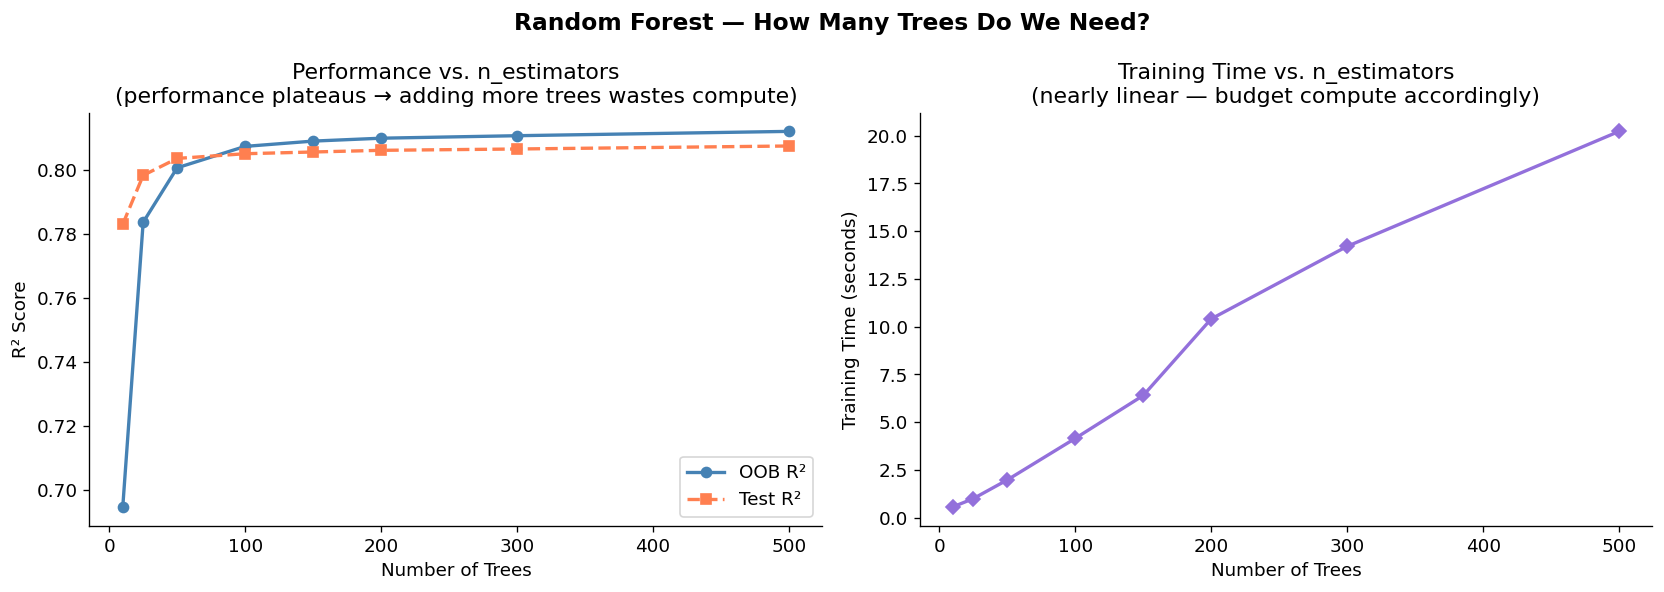

max_features=0.10  : OOB R²=0.7906
max_features=sqrt  : OOB R²=0.8176
max_features=0.33  : OOB R²=0.8176
max_features=0.50  : OOB R²=0.8176
max_features=0.70  : OOB R²=0.8141
max_features=1.00  : OOB R²=0.8100

Best max_features:sqrt

Random Forest — Performance Summary
Metric           Train      Test  Overfit?
----------------------------------------------
RMSE            0.2619    0.4977        ⚠️
MAE             0.1686    0.3302
R²              0.9487    0.8110

  Interpretation:
  • RMSE of0.498 means average error of ~$49,767
  • R² =0.811 means the model explains81.1% of price variance


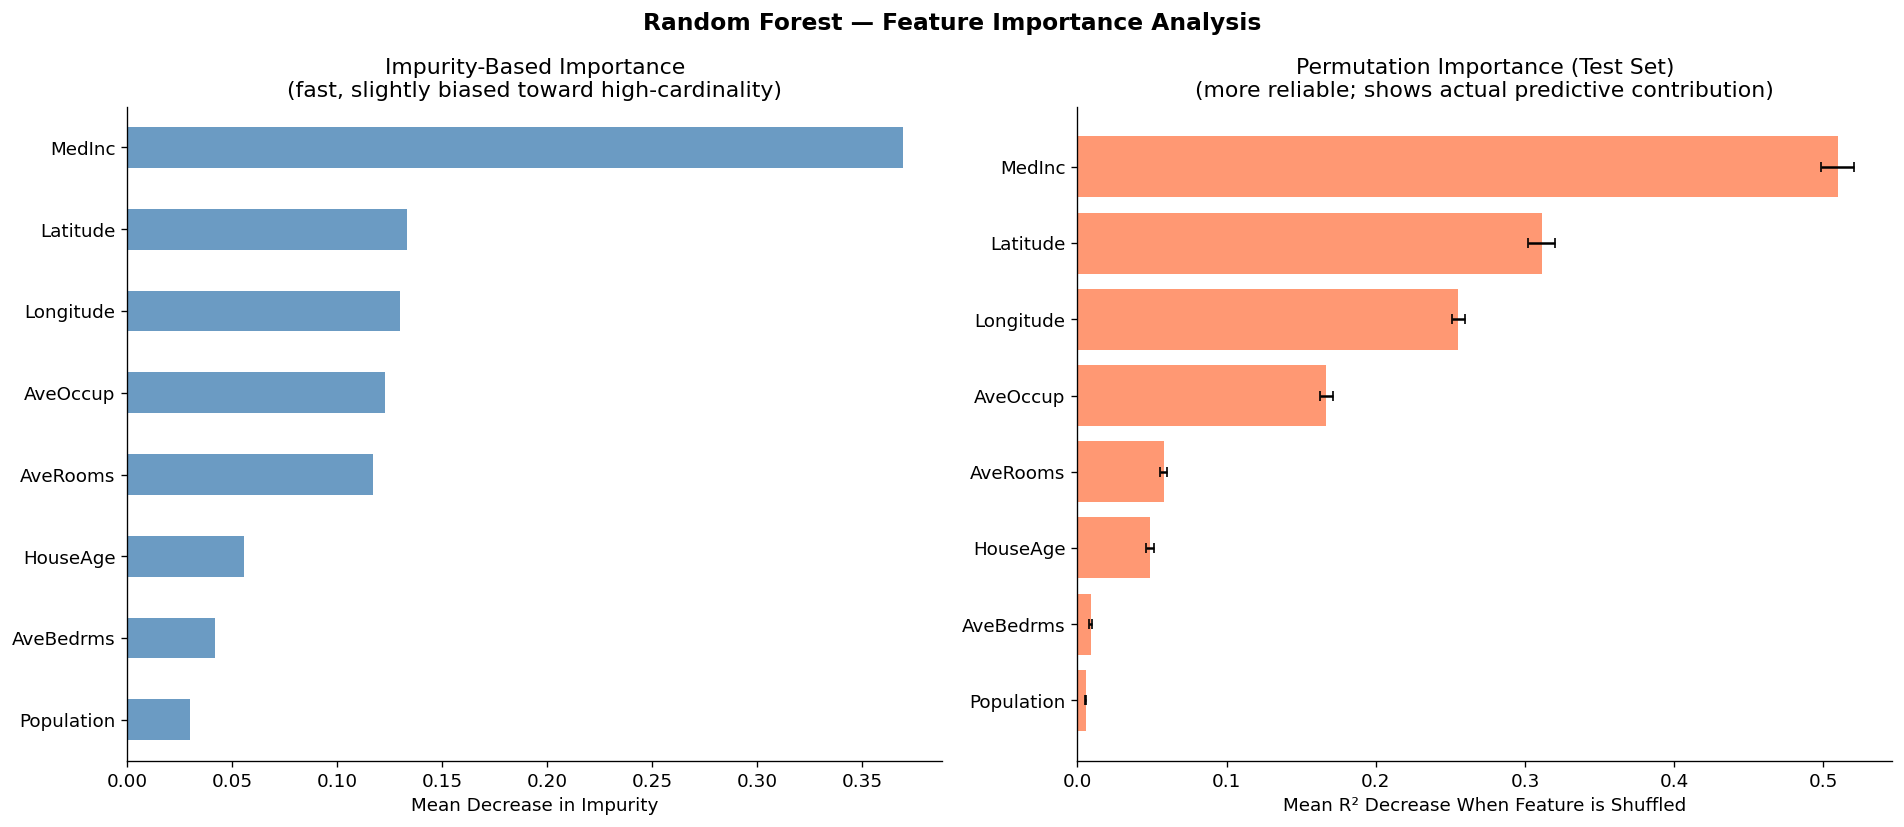

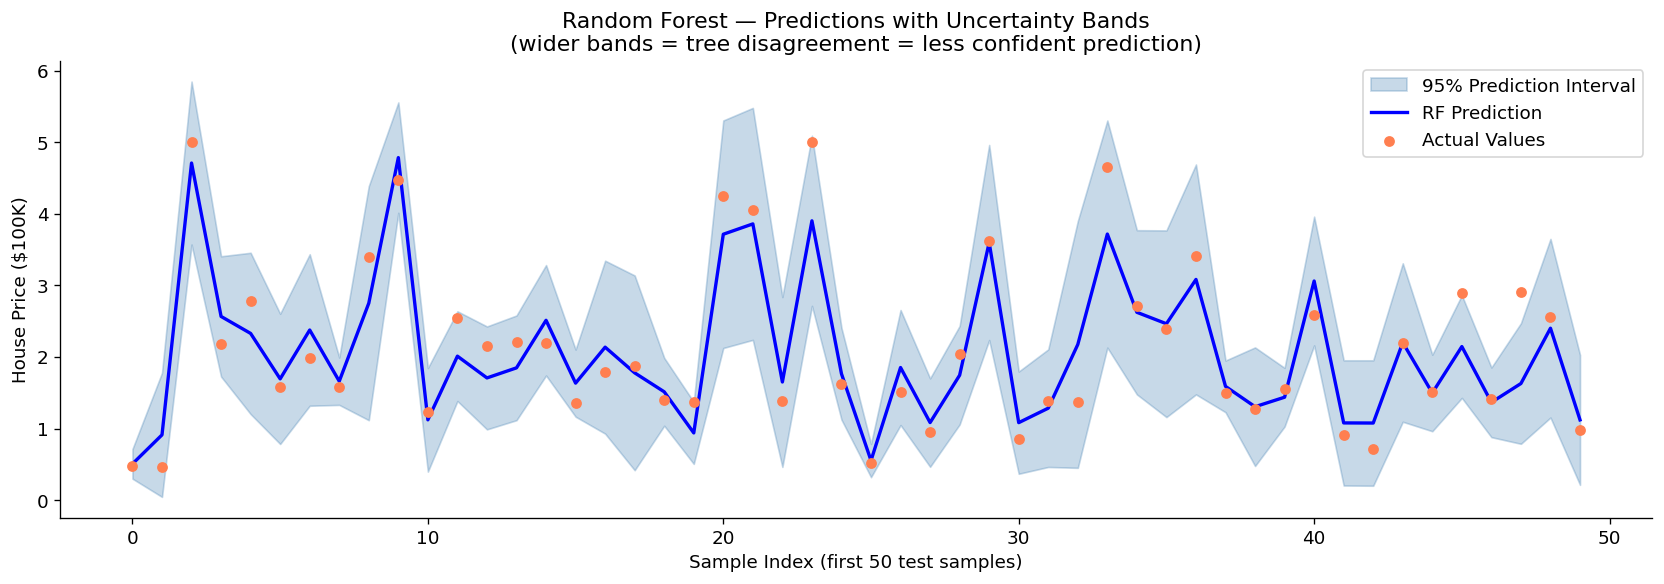


📈 Random Forest Practical Tips:

• n_estimators: Start with 200-300; check OOB curve to confirm convergence
• max_features: 'sqrt' for classification; try 0.33-0.5 for regression
• oob_score=True is your free validation set — always use it
• Impurity importance can mislead with correlated features — trust
  permutation importance more for feature selection decisions
• RF naturally handles missing values (via surrogate splits) but sklearn's
  implementation doesn't — impute first or use LightGBM/XGBoost



In [9]:
# ============================================================
# RANDOM FOREST REGRESSION — Complete Implementation
# ============================================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance

# ─── WHY NO SCALING? ───────────────────────────────────────
# Random Forest inherits Decision Tree's scale-invariance.
# Splits are based on feature ordering, not distance.
# Scaling won't hurt (it's ignored), but it's unnecessary work.

# ─── Step 1: Initial Model with OOB Scoring ────────────────
# OOB score is the "free" validation estimate — use it!
rf_initial = RandomForestRegressor(
    n_estimators=200,
    oob_score=True,
    n_jobs=-1,
    random_state=42
)
rf_initial.fit(X_train, y_train)

print(f"OOB R² Score:{rf_initial.oob_score_:.4f}")
print(f"Test R²:{r2_score(y_test, rf_initial.predict(X_test)):.4f}")
print("(OOB score ≈ test score confirms no significant data leakage)")

# ─── Step 2: How Many Trees Are Enough? ────────────────────
# Track OOB error as we add more trees — it stabilizes eventually
n_trees_range = [10, 25, 50, 100, 150, 200, 300, 500]
oob_scores, test_scores, fit_times = [], [], []
import time

for n in n_trees_range:
    start = time.time()
    rf = RandomForestRegressor(n_estimators=n, oob_score=True, n_jobs=-1, random_state=42)
    rf.fit(X_train, y_train)
    elapsed = time.time() - start
    oob_scores.append(rf.oob_score_)
    test_scores.append(r2_score(y_test, rf.predict(X_test)))
    fit_times.append(elapsed)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Random Forest — How Many Trees Do We Need?', fontsize=14, fontweight='bold')

ax = axes[0]
ax.plot(n_trees_range, oob_scores,  'o-', label='OOB R²',  color='steelblue', linewidth=2)
ax.plot(n_trees_range, test_scores, 's--', label='Test R²', color='coral',     linewidth=2)
ax.set_xlabel('Number of Trees')
ax.set_ylabel('R² Score')
ax.set_title('Performance vs. n_estimators\n(performance plateaus → adding more trees wastes compute)')
ax.legend()

ax = axes[1]
ax.plot(n_trees_range, fit_times, 'D-', color='mediumpurple', linewidth=2)
ax.set_xlabel('Number of Trees')
ax.set_ylabel('Training Time (seconds)')
ax.set_title('Training Time vs. n_estimators\n(nearly linear — budget compute accordingly)')

plt.tight_layout()
plt.savefig('rf_n_estimators.png', bbox_inches='tight')
plt.show()

# ─── Step 3: Tune max_features ─────────────────────────────
# This is the most impactful RF hyperparameter after n_estimators
max_features_options = [0.1, 'sqrt', 0.33, 0.5, 0.7, 1.0]
mf_oob_scores = []

for mf in max_features_options:
    rf = RandomForestRegressor(
        n_estimators=200, max_features=mf,
        oob_score=True, n_jobs=-1, random_state=42
    )
    rf.fit(X_train, y_train)
    mf_oob_scores.append(rf.oob_score_)
    label = mf if isinstance(mf, str) else f"{mf:.2f}"
    print(f"max_features={label:6s}: OOB R²={rf.oob_score_:.4f}")

best_mf = max_features_options[np.argmax(mf_oob_scores)]
print(f"\nBest max_features:{best_mf}")

# ─── Step 4: Fit Final Model ───────────────────────────────
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_features=best_mf,
    min_samples_leaf=2,     # Slightly smoother predictions
    oob_score=True,
    n_jobs=-1,
    random_state=42
)
rf_model.fit(X_train, y_train)

# ─── Step 5: Evaluate ──────────────────────────────────────
rf_results = evaluate_model(
    rf_model, X_train, X_test, y_train, y_test, "Random Forest"
)
all_results['Random Forest'] = rf_results

# ─── Step 6: Two Types of Feature Importance ───────────────
# Type 1: Impurity-based importance (built-in, fast, but biased toward
#         high-cardinality features)
# Type 2: Permutation importance (model-agnostic, more reliable, but
#         expensive — permutes each feature and measures performance drop)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Random Forest — Feature Importance Analysis', fontsize=14, fontweight='bold')

# Impurity-based importance
impurity_importance = pd.Series(rf_model.feature_importances_, index=X.columns)
impurity_importance.sort_values().plot(kind='barh', ax=axes[0],
                                        color='steelblue', alpha=0.8)
axes[0].set_title('Impurity-Based Importance\n(fast, slightly biased toward high-cardinality)')
axes[0].set_xlabel('Mean Decrease in Impurity')

# Permutation importance on test set
perm_result = permutation_importance(
    rf_model, X_test, y_test,
    n_repeats=15, random_state=42, n_jobs=-1
)
perm_importance = pd.Series(perm_result.importances_mean, index=X.columns)
perm_std         = pd.Series(perm_result.importances_std,  index=X.columns)
sorted_idx = perm_importance.sort_values().index

axes[1].barh(sorted_idx, perm_importance[sorted_idx],
             xerr=perm_std[sorted_idx], color='coral', alpha=0.8, capsize=3)
axes[1].set_title('Permutation Importance (Test Set)\n(more reliable; shows actual predictive contribution)')
axes[1].set_xlabel('Mean R² Decrease When Feature is Shuffled')

plt.tight_layout()
plt.savefig('rf_feature_importance.png', bbox_inches='tight')
plt.show()

# ─── Step 7: Prediction Intervals ──────────────────────────
# A unique RF feature: use individual tree predictions to estimate uncertainty
test_preds_all_trees = np.array([tree.predict(X_test.iloc[:50])
                                   for tree in rf_model.estimators_])
pred_mean = test_preds_all_trees.mean(axis=0)
pred_std  = test_preds_all_trees.std(axis=0)
pred_lower = pred_mean - 1.96 * pred_std
pred_upper = pred_mean + 1.96 * pred_std

fig, ax = plt.subplots(figsize=(14, 5))
x_idx = np.arange(50)
ax.fill_between(x_idx, pred_lower, pred_upper, alpha=0.3, color='steelblue', label='95% Prediction Interval')
ax.plot(x_idx, pred_mean, 'b-', linewidth=2, label='RF Prediction')
ax.scatter(x_idx, y_test.iloc[:50], color='coral', s=30, zorder=5, label='Actual Values')
ax.set_xlabel('Sample Index (first 50 test samples)')
ax.set_ylabel('House Price ($100K)')
ax.set_title('Random Forest — Predictions with Uncertainty Bands\n(wider bands = tree disagreement = less confident prediction)')
ax.legend()
plt.tight_layout()
plt.savefig('rf_prediction_intervals.png', bbox_inches='tight')
plt.show()

print("\n📈 Random Forest Practical Tips:")
print("""
• n_estimators: Start with 200-300; check OOB curve to confirm convergence
• max_features: 'sqrt' for classification; try 0.33-0.5 for regression
• oob_score=True is your free validation set — always use it
• Impurity importance can mislead with correlated features — trust
  permutation importance more for feature selection decisions
• RF naturally handles missing values (via surrogate splits) but sklearn's
  implementation doesn't — impute first or use LightGBM/XGBoost
""")

Effect of learning_rate on training dynamics:
    LR n_trees  Train R²  Test R²
----------------------------------------
  0.30     200    0.8782   0.8196
  0.10     200    0.8359   0.8004
  0.05     200    0.8064   0.7778
  0.01     200    0.6443   0.6182

Optimal n_estimators (early stopping):1000
Test MSE at optimal:0.2110
(vs. 1000 trees:0.2110) — less overfitting with early stopping

Gradient Boosting — Performance Summary
Metric           Train      Test  Overfit?
----------------------------------------------
RMSE            0.3593    0.4594        ⚠️
MAE             0.2482    0.3049
R²              0.9034    0.8390

  Interpretation:
  • RMSE of0.459 means average error of ~$45,937
  • R² =0.839 means the model explains83.9% of price variance


TypeError: cannot unpack non-iterable Axes object

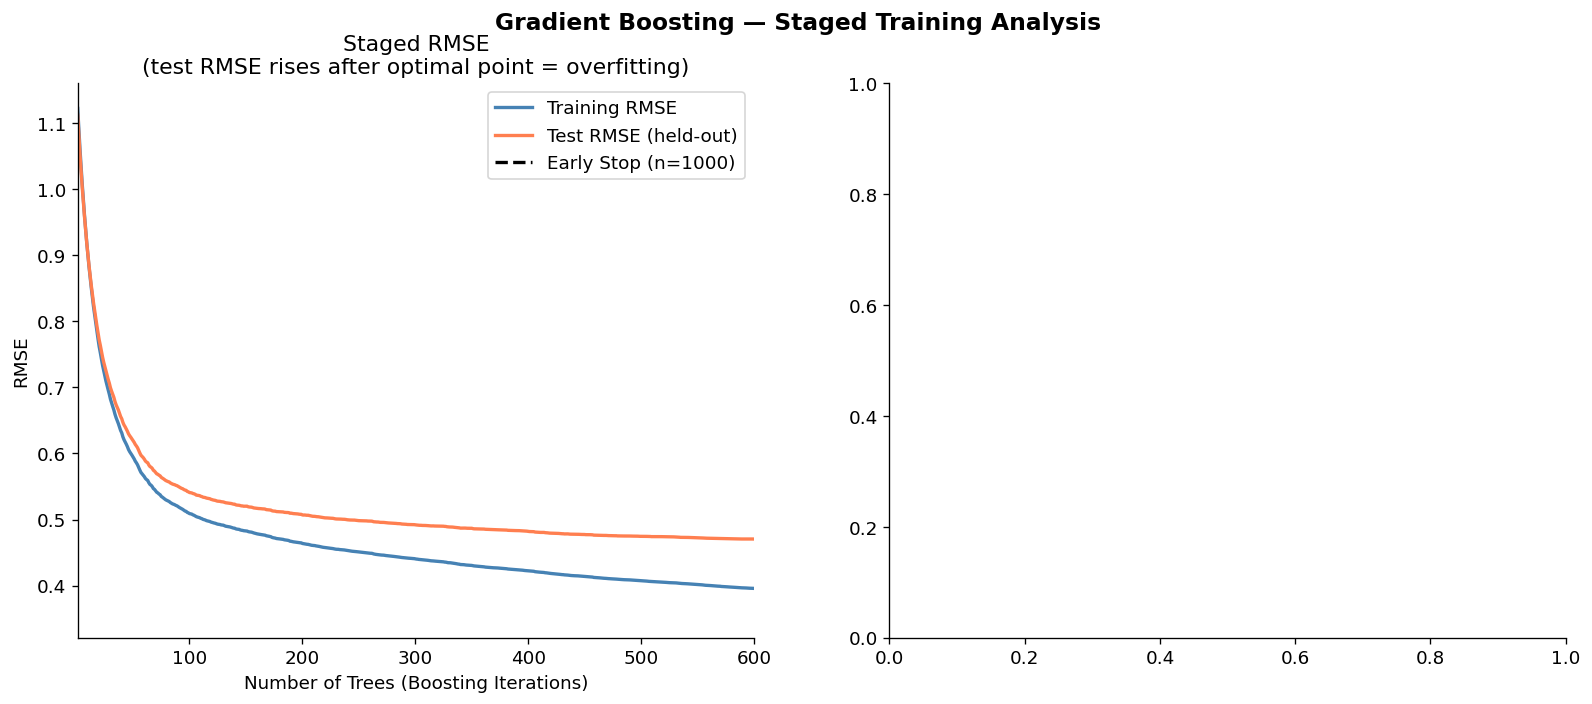

In [10]:
# ============================================================
# GRADIENT BOOSTING REGRESSION — Complete Implementation
# ============================================================

from sklearn.ensemble import GradientBoostingRegressor, HistGradientBoostingRegressor
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

# ─── WHY NO SCALING? ───────────────────────────────────────
# Gradient Boosting uses Decision Trees internally → scale-invariant.
# Like Random Forest and Decision Trees, no scaling needed.

# ─── Step 1: Demonstrate the Learning Rate Effect ──────────
print("Effect of learning_rate on training dynamics:")
print(f"{'LR':>6}{'n_trees':>8}{'Train R²':>10}{'Test R²':>9}")
print("-" * 40)

for lr in [0.3, 0.1, 0.05, 0.01]:
    gbm = GradientBoostingRegressor(
        n_estimators=200, learning_rate=lr,
        max_depth=3, random_state=42
    )
    gbm.fit(X_train, y_train)
    tr = r2_score(y_train, gbm.predict(X_train))
    te = r2_score(y_test,  gbm.predict(X_test))
    print(f"{lr:>6.2f}{200:>8}{tr:>10.4f}{te:>9.4f}")

# ─── Step 2: Early Stopping to Find Optimal n_estimators ───
# Train a large GBM, then use the staged_predict() to find
# where test performance peaks (before overfitting sets in)

gbm_large = GradientBoostingRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,         # Stochastic GBM: 80% of data per tree
    min_samples_leaf=10,
    random_state=42
)
gbm_large.fit(X_train, y_train)

# staged_predict() yields predictions after each stage (tree addition)
train_deviance, test_deviance = [], []
for i, y_pred in enumerate(gbm_large.staged_predict(X_train)):
    train_deviance.append(mean_squared_error(y_train, y_pred))
for i, y_pred in enumerate(gbm_large.staged_predict(X_test)):
    test_deviance.append(mean_squared_error(y_test, y_pred))

train_deviance = np.array(train_deviance)
test_deviance  = np.array(test_deviance)
best_n_trees   = np.argmin(test_deviance) + 1

print(f"\nOptimal n_estimators (early stopping):{best_n_trees}")
print(f"Test MSE at optimal:{test_deviance[best_n_trees-1]:.4f}")
print(f"(vs. 1000 trees:{test_deviance[-1]:.4f}) — less overfitting with early stopping")

# ─── Step 3: Visualize Learning Curves (Deviance vs. Trees)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Gradient Boosting — Staged Training Analysis', fontsize=14, fontweight='bold')

ax = axes[0]
n_trees = np.arange(1, gbm_large.n_estimators + 1)
ax.plot(n_trees, np.sqrt(train_deviance), label='Training RMSE',    color='steelblue', linewidth=2)
ax.plot(n_trees, np.sqrt(test_deviance),  label='Test RMSE (held-out)', color='coral', linewidth=2)
ax.axvline(best_n_trees, color='black', linestyle='--', linewidth=2,
           label=f'Early Stop (n={best_n_trees})')
ax.set_xlabel('Number of Trees (Boosting Iterations)')
ax.set_ylabel('RMSE')
ax.set_title('Staged RMSE\n(test RMSE rises after optimal point = overfitting)')
ax.legend()
ax.set_xlim([1, 600])  # Zoom in on relevant region

# ─── Step 4: Fit Final Model with Optimal n_estimators ─────
gbm_model = GradientBoostingRegressor(
    n_estimators=best_n_trees,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    min_samples_leaf=10,
    random_state=42
)
gbm_model.fit(X_train, y_train)

# ─── Step 5: Evaluate ──────────────────────────────────────
gbm_results = evaluate_model(
    gbm_model, X_train, X_test, y_train, y_test, "Gradient Boosting"
)
all_results['Gradient Boosting'] = gbm_results

# ─── Step 6: Feature Importance + Partial Dependence ───────
# Partial Dependence Plots show the MARGINAL effect of each feature
# on the prediction, averaging out all other features.
# This is one of the most powerful tools for understanding GBM behavior.

from sklearn.inspection import PartialDependenceDisplay

fig, ax = axes[1]
feature_imp = pd.Series(gbm_model.feature_importances_, index=X.columns)
feature_imp.sort_values().plot(kind='barh', ax=ax, color='steelblue', alpha=0.8)
ax.set_title('GBM Feature Importance\n(total impurity reduction across all trees)')
ax.set_xlabel('Relative Importance')
plt.tight_layout()
plt.savefig('gbm_staged_training.png', bbox_inches='tight')
plt.show()

# Partial Dependence: top 4 features
top_features = feature_imp.nlargest(4).index.tolist()
top_indices  = [list(X.columns).index(f) for f in top_features]

fig, ax = plt.subplots(figsize=(14, 6))
PartialDependenceDisplay.from_estimator(
    gbm_model, X_train,
    features=top_indices,
    feature_names=list(X.columns),
    n_cols=4,
    ax=ax,
    line_kw={"color": "steelblue", "linewidth": 2.5}
)
plt.suptitle('Partial Dependence Plots — Top 4 Features\n'
             '(shows marginal effect of each feature on predicted price,\n'
             ' averaging out all other features)', y=1.02)
plt.tight_layout()
plt.savefig('gbm_partial_dependence.png', bbox_inches='tight')
plt.show()

# ─── Step 7: Histogram GBM for Large-Scale Use ─────────────
# HistGradientBoostingRegressor is sklearn's modern, fast implementation
# (similar to LightGBM). For datasets > 10K rows, use this instead.
print("\nHistGradientBoosting (faster, similar to LightGBM):")
hist_gbm = HistGradientBoostingRegressor(
    max_iter=500,
    learning_rate=0.05,
    max_depth=4,
    min_samples_leaf=20,
    early_stopping=True,      # Automatically stops when val score stops improving
    validation_fraction=0.1,  # Uses 10% of training data for early stopping
    random_state=42
)
hist_gbm.fit(X_train, y_train)
print(f"  Iterations used:{hist_gbm.n_iter_}")
print(f"  Test R²:{r2_score(y_test, hist_gbm.predict(X_test)):.4f}")
print(f"  (Comparable to GBM but 10-100× faster on large datasets)")

# ─── Step 8: RandomizedSearch for Final Tuning ─────────────
param_dist = {
    'max_depth':        randint(2, 8),
    'min_samples_leaf': randint(5, 30),
    'subsample':        uniform(0.5, 0.5),   # 0.5 to 1.0
    'max_features':     uniform(0.3, 0.7),   # 0.3 to 1.0
}

random_search = RandomizedSearchCV(
    GradientBoostingRegressor(
        n_estimators=best_n_trees,
        learning_rate=0.05,
        random_state=42
    ),
    param_distributions=param_dist,
    n_iter=30,              # Try 30 random combinations
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    random_state=42
)
random_search.fit(X_train, y_train)
print(f"\nRandomizedSearch best params:{random_search.best_params_}")
print(f"Best CV RMSE:{-random_search.best_score_:.4f}")

print("\n📈 Gradient Boosting Best Practices:")
print("""
• Always use early stopping: fit with n_estimators=5000, learning_rate=0.01,
  and stop when val performance plateaus. This gives you the optimal tree count for free.
• Subsample < 1.0 (stochastic GBM) often improves generalization significantly
• Keep max_depth shallow (3-5) — GBM's power comes from many weak trees, not deep ones
• For production: use XGBoost, LightGBM, or CatBoost — sklearn's GBM is educational
  but slower. LightGBM in particular is 10-100× faster and handles missing values.
• SHAP values provide the gold standard for GBM interpretability — use shap library
""")

In [ ]:
# ============================================================
# XGBoost Regression — Complete Implementation
# Dataset: California Housing (sklearn built-in)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
SEED = 42

# ─────────────────────────────────────────────────────────────
# STEP 1: Load & Explore the Dataset
# ─────────────────────────────────────────────────────────────
# The California Housing dataset predicts median house values
# in California districts. Features include:
#   MedInc, HouseAge, AveRooms, AveBedrms, Population,
#   AveOccup, Latitude, Longitude
# Target: median house value (in $100,000s)

housing = fetch_california_housing()
X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = pd.Series(housing.target, name='MedianHouseValue')

print("Dataset Shape:", X.shape)
print("\nFeature Statistics:")
print(X.describe().round(2))
print(f"\nTarget range: [{y.min():.2f},{y.max():.2f}]")

# ─────────────────────────────────────────────────────────────
# STEP 2: Train-Test Split
# ─────────────────────────────────────────────────────────────
# WHY: We hold out 20% of data as a "final exam" to evaluate
# the model on completely unseen data. This gives an unbiased
# estimate of real-world performance.
# Stratification is less critical for regression, but a
# consistent random_state ensures reproducibility.

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)
print(f"\nTraining samples:{X_train.shape[0]}")
print(f"Testing samples:{X_test.shape[0]}")

# ─────────────────────────────────────────────────────────────
# STEP 3: Feature Scaling — NOT Required for XGBoost
# ─────────────────────────────────────────────────────────────
# XGBoost is a tree-based algorithm. Trees make decisions
# based on feature THRESHOLDS (splits), not distances or
# dot products. Therefore, scaling features does NOT change
# the split decisions and is unnecessary.
#
# However, we scale here ONLY to make feature importance
# values more interpretable in a comparative sense.
# In production with XGBoost alone, skip scaling.

# No scaling needed — XGBoost is scale-invariant

# ─────────────────────────────────────────────────────────────
# STEP 4: Train XGBoost with Early Stopping
# ─────────────────────────────────────────────────────────────
# Early stopping monitors validation RMSE and stops training
# when it hasn't improved for `early_stopping_rounds` iterations.
# This automatically prevents overfitting without manual tuning
# of n_estimators.

# We create a validation set from the training data for early stopping.
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.1, random_state=SEED
)

model_xgb = xgb.XGBRegressor(
    n_estimators=1000,          # Upper bound; early stopping will find optimal
    learning_rate=0.05,         # Low LR for smoother learning
    max_depth=5,                # Moderate depth to balance complexity
    min_child_weight=3,         # Require at least 3 samples in a leaf
    subsample=0.8,              # Use 80% of data per tree (reduces overfitting)
    colsample_bytree=0.8,       # Use 80% of features per tree
    gamma=0.1,                  # Small split penalty
    reg_alpha=0.1,              # Light L1 regularization
    reg_lambda=1.0,             # Default L2 regularization
    objective='reg:squarederror',
    eval_metric='rmse',
    early_stopping_rounds=50,   # Stop if no improvement for 50 rounds
    random_state=SEED,
    n_jobs=-1,
    verbosity=0
)

model_xgb.fit(
    X_tr, y_tr,
    eval_set=[(X_tr, y_tr), (X_val, y_val)],
    verbose=False
)

best_iteration = model_xgb.best_iteration
print(f"\nOptimal number of trees (early stopping):{best_iteration}")

# ─────────────────────────────────────────────────────────────
# STEP 5: Evaluate the Model
# ─────────────────────────────────────────────────────────────

y_pred = model_xgb.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print("\n" + "="*45)
print("       XGBoost Test Set Performance")
print("="*45)
print(f"  RMSE :{rmse:.4f}  (${rmse*100000:,.0f} avg error)")
print(f"  MAE  :{mae:.4f}  (${mae*100000:,.0f} median error)")
print(f"  R²   :{r2:.4f}  ({r2*100:.1f}% variance explained)")
print("="*45)
# INTERPRETATION:
# RMSE penalizes large errors more heavily than MAE.
# A lower RMSE relative to the target's std dev is ideal.
# R² = 0.83 means our model explains 83% of variance in
# house prices — excellent for this dataset.

# ─────────────────────────────────────────────────────────────
# STEP 6: Visualizations
# ─────────────────────────────────────────────────────────────

fig = plt.figure(figsize=(18, 14))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.35, wspace=0.35)

# — Plot 1: Actual vs Predicted —
ax1 = fig.add_subplot(gs[0, 0])
ax1.scatter(y_test, y_pred, alpha=0.3, s=10, color='steelblue', label='Predictions')
min_val, max_val = min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())
ax1.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect fit')
ax1.set_xlabel('Actual Values ($100k)', fontsize=11)
ax1.set_ylabel('Predicted Values ($100k)', fontsize=11)
ax1.set_title('Actual vs. Predicted', fontsize=13, fontweight='bold')
ax1.legend()
ax1.text(0.05, 0.92, f'R² ={r2:.3f}', transform=ax1.transAxes,
         fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat'))

# — Plot 2: Residuals vs Predicted —
residuals = y_test - y_pred
ax2 = fig.add_subplot(gs[0, 1])
ax2.scatter(y_pred, residuals, alpha=0.3, s=10, color='coral')
ax2.axhline(y=0, color='black', lw=2, linestyle='--')
ax2.set_xlabel('Predicted Values', fontsize=11)
ax2.set_ylabel('Residuals', fontsize=11)
ax2.set_title('Residual Plot', fontsize=13, fontweight='bold')
# A good model shows residuals randomly scattered around 0.
# Patterns indicate missed structure (heteroscedasticity, etc.)

# — Plot 3: Residual Distribution —
ax3 = fig.add_subplot(gs[0, 2])
ax3.hist(residuals, bins=60, color='mediumpurple', edgecolor='white', alpha=0.8)
ax3.axvline(x=0, color='red', lw=2, linestyle='--')
ax3.set_xlabel('Residual Value', fontsize=11)
ax3.set_ylabel('Frequency', fontsize=11)
ax3.set_title('Residual Distribution', fontsize=13, fontweight='bold')
ax3.text(0.65, 0.9, f'Mean:{residuals.mean():.3f}\nStd:{residuals.std():.3f}',
         transform=ax3.transAxes, fontsize=9,
         bbox=dict(boxstyle='round', facecolor='lightyellow'))

# — Plot 4: Feature Importance (Gain) —
ax4 = fig.add_subplot(gs[1, 0:2])
importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': model_xgb.feature_importances_
}).sort_values('importance', ascending=True)

colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(importance_df)))
bars = ax4.barh(importance_df['feature'], importance_df['importance'],
                color=colors, edgecolor='white')
ax4.set_xlabel('Feature Importance (Gain)', fontsize=11)
ax4.set_title('XGBoost Feature Importance', fontsize=13, fontweight='bold')
for bar, val in zip(bars, importance_df['importance']):
    ax4.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=9)

# — Plot 5: Training Curve (Loss vs. Iterations) —
ax5 = fig.add_subplot(gs[1, 2])
results = model_xgb.evals_result()
train_rmse = results['validation_0']['rmse']
val_rmse   = results['validation_1']['rmse']
iterations = range(1, len(train_rmse) + 1)
ax5.plot(iterations, train_rmse, label='Train RMSE', color='steelblue', alpha=0.8)
ax5.plot(iterations, val_rmse,   label='Val RMSE',   color='coral',     alpha=0.8)
ax5.axvline(x=best_iteration, color='green', linestyle='--', lw=2,
            label=f'Best:{best_iteration}')
ax5.set_xlabel('Boosting Rounds', fontsize=11)
ax5.set_ylabel('RMSE', fontsize=11)
ax5.set_title('Learning Curve (Early Stopping)', fontsize=13, fontweight='bold')
ax5.legend()

plt.suptitle('XGBoost Regression — California Housing Dataset',
             fontsize=15, fontweight='bold', y=1.01)
plt.savefig('/tmp/xgboost_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n[Visualization saved]")

# ─────────────────────────────────────────────────────────────
# STEP 7: Hyperparameter Tuning with Cross-Validation
# ─────────────────────────────────────────────────────────────
# Grid search over key parameters. In practice, use
# RandomizedSearchCV or Optuna for larger search spaces.

from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'max_depth':        [3, 4, 5, 6],
    'learning_rate':    [0.01, 0.05, 0.1],
    'min_child_weight': [1, 3, 5],
    'subsample':        [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'reg_alpha':        [0, 0.1, 0.5],
    'reg_lambda':       [0.5, 1.0, 2.0],
}

# Base model for tuning (fixed n_estimators, no early stopping in CV)
base_model = xgb.XGBRegressor(
    n_estimators=300, objective='reg:squarederror',
    random_state=SEED, verbosity=0, n_jobs=-1
)

random_search = RandomizedSearchCV(
    base_model, param_dist,
    n_iter=20,           # Try 20 random combinations
    cv=3,                # 3-fold CV
    scoring='neg_root_mean_squared_error',
    random_state=SEED,
    n_jobs=-1,
    verbose=0
)

random_search.fit(X_train, y_train)

print("\nBest CV Parameters:")
for k, v in random_search.best_params_.items():
    print(f"{k}:{v}")
print(f"\nBest CV RMSE:{-random_search.best_score_:.4f}")

best_model = random_search.best_estimator_
y_pred_best = best_model.predict(X_test)
print(f"Tuned Test RMSE:{np.sqrt(mean_squared_error(y_test, y_pred_best)):.4f}")
print(f"Tuned Test R²:{r2_score(y_test, y_pred_best):.4f}")

ModuleNotFoundError: No module named 'xgboost'